In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
long_table=pd.read_csv('源域数据32khz整理.csv')
long_table

,file,status,fault_size_inch,position,load,data_id,DE_time,FE_time,BA_time,RPM
0,源域数据集\48kHz_Normal_data\N_0.mat,N,0.000,NaN,0.0,X097,0.044571,0.102660,NaN,1796.0
1,源域数据集\48kHz_Normal_data\N_0.mat,N,0.000,NaN,0.0,X097,0.085841,0.044022,NaN,1796.0
2,源域数据集\48kHz_Normal_data\N_0.mat,N,0.000,NaN,0.0,X097,0.047885,0.009169,NaN,1796.0
3,源域数据集\48kHz_Normal_data\N_0.mat,N,0.000,NaN,0.0,X097,-0.047899,0.011196,NaN,1796.0
4,源域数据集\48kHz_Normal_data\N_0.mat,N,0.000,NaN,0.0,X097,-0.083827,-0.039196,NaN,1796.0
...,...,...,...,...,...,...,...,...,...,...
28569983,源域数据集\48kHz_DE_data\B\0007\B007_2.mat,B,0.007,NaN,2.0,X124,0.000000,0.000000,NaN,1747.0
28569984,源域数据集\48kHz_DE_data\B\0007\B007_2.mat,B,0.007,NaN,2.0,X124,0.000000,0.000000,NaN,1747.0
28569985,源域数据集\48kHz_DE_data\B\0007\B007_2.mat,B,0.007,NaN,2.0,X124,0.000000,0.000000,NaN,1747.0
28569986,源域数据集\48kHz_DE_data\B\0007\B007_2.mat,B,0.007,NaN,2.0,X124,0.000000,0.000000,NaN,1747.0


In [2]:
import numpy as np
import pandas as pd
from scipy.signal import hilbert, welch, stft
from scipy.stats import kurtosis, skew
import pywt

# ------------------ 工具函数 ------------------ #

def time_features(x):
    """时域统计特征"""
    x = np.asarray(x).ravel()
    if len(x) == 0:
        return {}
    rms = np.sqrt(np.mean(x**2))
    mean_abs = np.mean(np.abs(x))
    sqr_mean = np.mean(np.sqrt(np.abs(x)))
    peak = np.max(np.abs(x))

    feats = {
        "均值": np.mean(x),
        "标准差": np.std(x),
        "方差": np.var(x),
        "均方根": rms,
        "峰值": peak,
        "峰峰值": np.ptp(x),
        "平均绝对值": mean_abs,
        "波形指标": rms / (mean_abs + 1e-12),
        "峭度指标": peak / (rms + 1e-12),
        "脉冲指标": peak / (mean_abs + 1e-12),
        "裕度指标": peak / (sqr_mean**2 + 1e-12),
        "间隙指标": peak / (sqr_mean + 1e-12),
        "峭度": kurtosis(x),
        "偏度": skew(x),
    }
    return feats

def freq_features(x, fs, fr):
    """频域特征（转速归一化）"""
    f, Pxx = welch(x, fs=fs, nperseg=2048)
    Pxx = Pxx / np.sum(Pxx)  # 归一化功率谱

    # 转频归一化
    f_norm = f / fr  

    feats = {
        "谱质心": np.sum(f_norm * Pxx),
        "谱带宽": np.sqrt(np.sum(((f_norm - np.mean(f_norm))**2) * Pxx)),
        "谱偏度": skew(Pxx),
        "谱峭度": kurtosis(Pxx),
        "谱熵": -np.sum(Pxx * np.log(Pxx + 1e-12)),
    }

    # 带通能量（按 fr 倍频划分）
    bands = [(0.8,1.2),(1.8,2.2),(2.8,3.2),(4.5,5.5)]
    for i,(lo,hi) in enumerate(bands,1):
        mask = (f_norm>=lo)&(f_norm<=hi)
        feats[f"带通能量_{i}"] = np.sum(Pxx[mask])
    return feats

def tf_features(x, fs, fr):
    """时频域特征（STFT + 小波能量）"""
    # --- STFT ---
    f,t,Zxx = stft(x, fs=fs, nperseg=1024)
    power = np.abs(Zxx)**2
    power = power / (np.sum(power) + 1e-12)

    # 归一化频率
    f_norm = f / fr
    feats = {
        "时频熵": -np.sum(power * np.log(power + 1e-12)),
        "时频均值频率": np.sum(np.mean(power,axis=1)*f_norm),
    }

    # --- 小波分解 ---
    coeffs = pywt.wavedec(x, 'db4', level=4)
    energy = np.array([np.sum(c**2) for c in coeffs])
    energy_ratio = energy / (np.sum(energy)+1e-12)
    for i,e in enumerate(energy_ratio):
        feats[f"小波能量_{i}"] = e
    return feats



In [3]:
%%time

import numpy as np
import pandas as pd
from scipy.signal import stft, welch
from scipy.stats import kurtosis, skew
import pywt
import random

# ========= 思路 =========
'''
思路是：先用原始 long 表按文件提取每条信号的时域、频域与时频特征，并统计各“状态”的样本数；将目标设为每类 77 条。
对已满足目标的多数类（如 OR）不做处理；对少数类（如 B、IR、N），反复从该类已存在的原始信号中随机选取两条，按给定比例（如 50%）生成逐点二值掩码，
将两条信号在同一长度上对齐后按掩码逐点拼接得到“新信号”（约一半点来自样本 A、另一半来自样本 B，必要时可加微小噪声增加多样性）。
新样本继承其中一条原样本的 RPM 以计算转频归一化（fr），再用与原样本一致的特征提取流程得到特征并标注原状态，
循环生成直至该类样本数补齐到 77。最终将原样本与增广样本合并，得到各类数量均衡、特征一致的训练集。
'''

def extract_features_balanced_from_long(
    long_table: pd.DataFrame,
    signal_col: str = "DE_time",
    fs: int = 32000,
    target_per_class: int = 77,   # 目标：每个类别都补到 77
    mix_ratio: float = 0.5,       # “随机采用比例”（掩码中 1 的期望占比）
    random_state: int = 42        # 随机种子，保证可复现
):
    """
    基于原始 long 表进行采样与样本均衡：
    1) 先按文件提取原始特征；
    2) 对少数类用“随机二值掩码混合同类两条原始信号”的方式生成新信号，再提特征；
    3) 输出均衡后的特征矩阵 X 与标签 y（中文字段名）。
    
    参数
    ----
    long_table : pd.DataFrame
        必须包含列：'file', 'status', signal_col, 'RPM'
    signal_col : str
        信号列名（默认 'DE_time'）
    fs : int
        采样频率
    target_per_class : int
        每个类别最终样本数目标（默认 77）
    mix_ratio : float
        掩码中取第一条信号的比例（例如 0.5 表示 50% 点来自样本 A，50% 来自样本 B）
    random_state : int
        随机种子
    
    返回
    ----
    X_balanced : pd.DataFrame
        特征矩阵（索引为“文件名”，列为中文特征名）
    y_balanced : pd.Series
        标签序列（名为“状态”），与 X_balanced 对齐
    """
    rng = np.random.default_rng(random_state)
    random.seed(random_state)

    # -------- Step 1：先按文件提取“原始样本”的特征，并缓存原始信号用于后续合成 --------
    feature_rows = []
    labels = []
    # 为后续合成准备一个缓存：每个状态 -> [(file_id, x_array, rpm), ...]
    raw_pool = {}

    for fid, group in long_table.groupby("file"):
        x = group[signal_col].dropna().values
        if len(x) == 0:
            continue
        rpm = group["RPM"].iloc[0]
        fr = (rpm / 60.0) if (pd.notna(rpm) and rpm > 0) else 1.0
        status = group["status"].iloc[0]

        # 提取特征（中文字段名）
        feats = {}
        feats.update(time_features(x))
        feats.update(freq_features(x, fs, fr))
        feats.update(tf_features(x, fs, fr))
        feats["文件名"] = fid

        feature_rows.append(feats)
        labels.append(status)

        # 存入池子，便于后续做少数类的合成
        raw_pool.setdefault(status, []).append((fid, x, rpm))

    # 组装原始特征表
    X = pd.DataFrame(feature_rows).set_index("文件名")
    y = pd.Series(labels, index=X.index, name="状态")

    # -------- Step 2：统计每个类别当前数量，决定需要合成多少 --------
    counts = y.value_counts()
    # 只对少数类进行增广
    need_augment = {
        cls: max(0, target_per_class - cnt)
        for cls, cnt in counts.items()
    }

    # -------- Step 3：对少数类进行“随机掩码混合”合成新信号并提特征 --------
    aug_feature_rows = []
    aug_labels = []

    for cls, n_needed in need_augment.items():
        if n_needed <= 0:
            continue  # 该类已达到或超过目标，无需增广

        # 该类别的原始池
        pool = raw_pool.get(cls, [])
        if len(pool) == 0:
            # 没有原始样本，无法合成
            print(f"警告：类别 {cls} 在原始数据中不存在，无法增广。")
            continue
        if len(pool) == 1:
            # 只有一个样本时，用自身与自身“混合”，相当于随机抽取片段
            print(f"提示：类别 {cls} 只有 1 个原始样本，增广将以同一条信号自混合方式进行。")

        for k in range(n_needed):
            # 随机从该类中取两条（可重复）用于混合
            (fid_a, xa, rpm_a) = random.choice(pool)
            (fid_b, xb, rpm_b) = random.choice(pool)

            # 对齐长度（截断到最短长度）
            L = min(len(xa), len(xb))
            xa_ = xa[:L]
            xb_ = xb[:L]

            # 生成随机0/1掩码（mix_ratio 的比例来自 xa，其余来自 xb）
            mask = rng.random(L) < mix_ratio
            # 逐点拼接（掩码为 True 取 xa，否则取 xb）
            x_new = np.where(mask, xa_, xb_)

            # 也可加一点极小高斯噪声，打破完全重复（可选）
            # noise = rng.normal(0, 1e-6*np.std(x_new) if np.std(x_new)>0 else 1e-6, size=L)
            # x_new = x_new + noise

            # 用 A 的 RPM 作为该新样本的转速（也可以随机在 A/B 中选一个）
            rpm_new = rpm_a
            fr_new = (rpm_new / 60.0) if (pd.notna(rpm_new) and rpm_new > 0) else 1.0

            # 提取新样本特征
            feats_new = {}
            feats_new.update(time_features(x_new))
            feats_new.update(freq_features(x_new, fs, fr_new))
            feats_new.update(tf_features(x_new, fs, fr_new))

            # 新样本的“文件名”（索引）；标注清晰：来源文件 + 序号
            new_id = f"{fid_a}__aug_{k+1:03d}_cls_{cls}"
            feats_new["文件名"] = new_id

            aug_feature_rows.append(feats_new)
            aug_labels.append(cls)

    # -------- Step 4：合并原始与增广后的特征，并返回 --------
    if len(aug_feature_rows) > 0:
        X_aug = pd.DataFrame(aug_feature_rows).set_index("文件名")
        y_aug = pd.Series(aug_labels, index=X_aug.index, name="状态")
        X_balanced = pd.concat([X, X_aug], axis=0)
        y_balanced = pd.concat([y, y_aug], axis=0)
    else:
        X_balanced, y_balanced = X, y

    # 可选：检查均衡结果
    print("均衡后各类数量：")
    print(y_balanced.value_counts())

    return X_balanced, y_balanced

X_bal, y_bal = extract_features_balanced_from_long(
    long_table,
    signal_col="DE_time",
    fs=32000,
    target_per_class=77,  # 按你的需要，这里统一凑到 77
    mix_ratio=0.5,        # “随机采用其中50%”
    random_state=42
)

# 看看均衡效果
y_bal.value_counts()


均衡后各类数量：
状态
B     77
IR    77
OR    77
N     77
Name: count, dtype: int64
CPU times: total: 18.3 s
Wall time: 18.9 s


状态
B     77
IR    77
OR    77
N     77
Name: count, dtype: int64

In [4]:


# -------- 1. 提取三路特征 --------
X_DE, y_DE = extract_features_balanced_from_long(long_table, signal_col="DE_time", fs=32000)
X_FE, y_FE = extract_features_balanced_from_long(long_table, signal_col="FE_time", fs=32000)
X_BA, y_BA = extract_features_balanced_from_long(long_table, signal_col="BA_time", fs=32000)


均衡后各类数量：
状态
B     77
IR    77
OR    77
N     77
Name: count, dtype: int64
均衡后各类数量：
状态
B     77
IR    77
OR    77
N     77
Name: count, dtype: int64
均衡后各类数量：
状态
B     77
IR    77
OR    77
Name: count, dtype: int64


In [5]:

# -------- 2. 重置索引 --------
X_DE.reset_index(inplace=True, drop=True)
X_FE.reset_index(inplace=True, drop=True)
X_BA.reset_index(inplace=True, drop=True)
y_DE.reset_index(inplace=True, drop=True)
y_FE.reset_index(inplace=True, drop=True)
y_BA.reset_index(inplace=True, drop=True)


In [6]:

# -------- 3. 合并 --------
# 拼接特征（横向拼接）
X_bal = pd.concat([X_DE, X_FE, X_BA], axis=0)

# 标签（这里假设三路特征的样本对应相同顺序，否则需单独对齐）
y_bal =pd.concat([y_DE, y_FE, y_BA], axis=0)

print("合并后特征矩阵形状:", X_bal.shape)
print("合并后标签形状:", y_bal.shape)


合并后特征矩阵形状: (847, 30)
合并后标签形状: (847,)


In [7]:

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif']=['SimHei'] # 中文支持
plt.rcParams['axes.unicode_minus']=False

import warnings
warnings.filterwarnings('ignore')

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
import pandas as pd

# 基学习器，这里用随机森林
estimator = RandomForestClassifier(n_estimators=100, random_state=42)

# 构造RFE，选择保留的特征数，可以调整 n_features_to_select
selector = RFE(estimator, n_features_to_select=20, step=1)  # 保留20个特征

# 拟合RFE
selector = selector.fit(X_bal, y_bal)

# 被选择的特征
selected_features = X_bal.columns[selector.support_]

# 输出选择的特征
print("选择的特征：")
print(selected_features)

# 构造新的特征矩阵
X_selected = X_bal[selected_features]

# 输出最终的形状
print("原始特征维度：", X_bal.shape[1])
print("筛选后特征维度：", X_selected.shape[1])


选择的特征：
Index(['标准差', '方差', '均方根', '峰值', '峰峰值', '平均绝对值', '波形指标', '峭度指标', '裕度指标', '峭度',
       '谱质心', '谱峭度', '带通能量_4', '时频熵', '时频均值频率', '小波能量_0', '小波能量_1', '小波能量_2',
       '小波能量_3', '小波能量_4'],
      dtype='object')
原始特征维度： 30
筛选后特征维度： 20


In [9]:
scaler = StandardScaler()
scaler.fit(X_selected)   # 用源域拟合
X_src_scaled = scaler.transform(X_selected)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize

# ========== 数据划分 ==========
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_bal, test_size=0.3, random_state=42, stratify=y_bal
)

# ========== 构建分类器 ==========
# ========== 构建分类器 ==========
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)

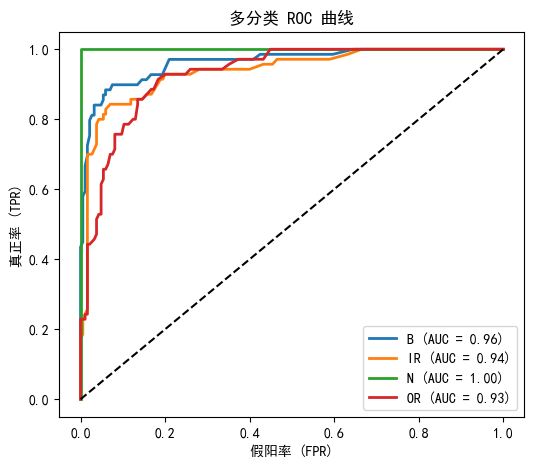

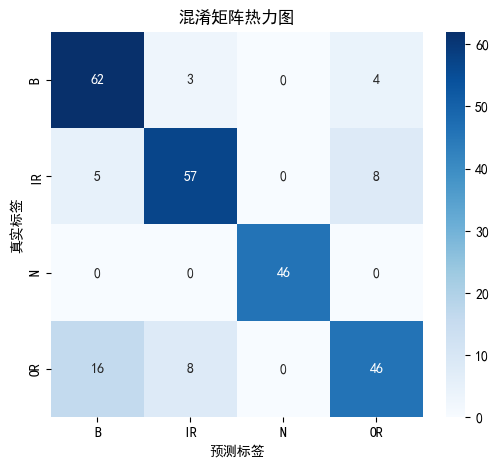

F1 分类报告：
              precision    recall  f1-score   support

           B       0.75      0.90      0.82        69
          IR       0.84      0.81      0.83        70
           N       1.00      1.00      1.00        46
          OR       0.79      0.66      0.72        70

    accuracy                           0.83       255
   macro avg       0.84      0.84      0.84       255
weighted avg       0.83      0.83      0.83       255



In [11]:
# ========== 1. ROC曲线 ==========
classes = np.unique(y_bal)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(6,5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("假阳率 (FPR)")
plt.ylabel("真正率 (TPR)")
plt.title("多分类 ROC 曲线")
plt.legend(loc="lower right")
plt.show()

# ========== 2. 混淆矩阵 ==========
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("预测标签")
plt.ylabel("真实标签")
plt.title("混淆矩阵热力图")
plt.show()

# ========== 3. F1 报告 ==========
print("F1 分类报告：")
print(classification_report(y_test, y_pred, target_names=classes))

In [12]:
# ====================== PSO 超参数寻优（不使用交叉验证）======================
# 思路：
# - 在 (X_train, y_train) 内再划一份验证集 (X_tr, X_val) 做单次 holdout；
# - 用 PSO 搜索随机森林的超参数，使得在验证集上的 F1_macro 得分最大；
# - 取得最优超参数后，在 (X_train)（即训练+验证合并）上重训，再到 X_test 上评估。

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import math
import time

# ---------- 1) 训练/验证划分（非交叉验证，仅一次性切分） ----------
X_tr, X_val, y_tr, y_val =X_train, X_test, y_train, y_test

# ---------- 2) 定义搜索空间 ----------
# 连续空间 -> 训练时取整（对整数超参），或直接用浮点（如 max_features 的比例）
SPACE = {
    "n_estimators": (50, 1000),       # 整数
    "max_depth":   (3, 50),          # 整数（不考虑 None，如需可放宽到[0,30]，0代表None）
    "min_samples_split": (2, 20),    # 整数
    "min_samples_leaf":  (1, 20)    # 整数

}

def decode_particle(vec):
    """将粒子实数向量映射为随机森林超参数字典"""
    (ne_lo, ne_hi) = SPACE["n_estimators"]
    (md_lo, md_hi) = SPACE["max_depth"]
    (mss_lo, mss_hi) = SPACE["min_samples_split"]
    (msl_lo, msl_hi) = SPACE["min_samples_leaf"]

    params = {
        "n_estimators": int(round(np.clip(vec[0], ne_lo, ne_hi))),
        "max_depth":    int(round(np.clip(vec[1], md_lo, md_hi))),
        "min_samples_split": int(round(np.clip(vec[2], mss_lo, mss_hi))),
        "min_samples_leaf":  int(round(np.clip(vec[3], msl_lo, msl_hi))),
        "random_state": 42,
        "n_jobs": -1,
    }
    # 边界条件修正（避免非法组合）
    params["min_samples_split"] = max(params["min_samples_split"], params["min_samples_leaf"]+0)  # split>=leaf 通常更稳
    return params

def evaluate_particle(vec):
    """以验证集 F1_macro 为目标函数（越大越好）"""
    params = decode_particle(vec)
    clf_pso = RandomForestClassifier(**params)
    clf_pso.fit(X_tr, y_tr)
    pred_val = clf_pso.predict(X_val)
    f1 = f1_score(y_val, pred_val, average="macro")
    return f1

# ---------- 3) PSO 主过程 ----------
# PSO 参数
NUM_DIM = 4
NUM_PARTICLES = 20
NUM_ITERS = 25
W = 0.72          # 惯性权重
C1 = 1.49         # 个体学习因子
C2 = 1.49         # 群体学习因子
rng = np.random.default_rng(2025)

# 初始化粒子（在每一维的空间范围内均匀随机）
LOWS  = np.array([SPACE["n_estimators"][0], SPACE["max_depth"][0], SPACE["min_samples_split"][0], SPACE["min_samples_leaf"][0]])
HIGHS = np.array([SPACE["n_estimators"][1], SPACE["max_depth"][1], SPACE["min_samples_split"][1], SPACE["min_samples_leaf"][1]])

positions = rng.uniform(LOWS, HIGHS, size=(NUM_PARTICLES, NUM_DIM))
velocities = rng.uniform(-np.abs(HIGHS-LOWS), np.abs(HIGHS-LOWS), size=(NUM_PARTICLES, NUM_DIM))*0.1

# 评估初值
pbest_pos = positions.copy()
pbest_val = np.array([evaluate_particle(p) for p in positions])

gbest_idx = int(np.argmax(pbest_val))
gbest_pos = pbest_pos[gbest_idx].copy()
gbest_val = float(pbest_val[gbest_idx])

print(f"[PSO] 初始最优 F1_macro = {gbest_val:.4f}，超参数 = {decode_particle(gbest_pos)}")

t0 = time.time()
for it in range(1, NUM_ITERS+1):
    # 更新速度与位置
    r1 = rng.random((NUM_PARTICLES, NUM_DIM))
    r2 = rng.random((NUM_PARTICLES, NUM_DIM))
    velocities = (
        W*velocities
        + C1*r1*(pbest_pos - positions)
        + C2*r2*(gbest_pos - positions)
    )
    positions = positions + velocities
    # 位置边界裁剪
    positions = np.minimum(np.maximum(positions, LOWS), HIGHS)

    # 评估
    vals = np.array([evaluate_particle(p) for p in positions])

    # 更新个体最优
    improved = vals > pbest_val
    pbest_pos[improved] = positions[improved]
    pbest_val[improved] = vals[improved]

    # 更新全局最优
    if pbest_val.max() > gbest_val:
        gbest_idx = int(np.argmax(pbest_val))
        gbest_pos = pbest_pos[gbest_idx].copy()
        gbest_val = float(pbest_val[gbest_idx])

    if it % 5 == 0 or it == NUM_ITERS:
        print(f"[PSO] 迭代 {it:02d}/{NUM_ITERS}，当前最优 F1_macro = {gbest_val:.4f}")

t1 = time.time()
print(f"[PSO] 完成。耗时 {t1 - t0:.1f}s")
best_params = decode_particle(gbest_pos)
print("[PSO] 最优超参数：", best_params)

# ---------- 4) 用最优超参数在训练集（X_train，全量）上重训，并在测试集评估 ----------
clf_best = RandomForestClassifier(**best_params)
clf_best.fit(X_train, y_train)

y_pred_best = clf_best.predict(X_test)
y_proba_best = clf_best.predict_proba(X_test)

f1_macro_test = f1_score(y_test, y_pred_best, average="macro")
print(f"[PSO] 最优模型在测试集上的 F1_macro：{f1_macro_test:.4f}")




[PSO] 初始最优 F1_macro = 0.7999，超参数 = {'n_estimators': 846, 'max_depth': 34, 'min_samples_split': 3, 'min_samples_leaf': 3, 'random_state': 42, 'n_jobs': -1}
[PSO] 迭代 05/25，当前最优 F1_macro = 0.8549
[PSO] 迭代 10/25，当前最优 F1_macro = 0.8592
[PSO] 迭代 15/25，当前最优 F1_macro = 0.8592
[PSO] 迭代 20/25，当前最优 F1_macro = 0.8592
[PSO] 迭代 25/25，当前最优 F1_macro = 0.8592
[PSO] 完成。耗时 470.7s
[PSO] 最优超参数： {'n_estimators': 1000, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1}
[PSO] 最优模型在测试集上的 F1_macro：0.8592


In [13]:
clf = RandomForestClassifier(** {'n_estimators': 60, 'max_depth': 49, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1})
clf.fit(X_selected, y_bal)

RandomForestClassifier(max_depth=49, n_estimators=60, n_jobs=-1,
                       random_state=42)

In [14]:
import pandas as pd
tgt_long=pd.read_csv('目标域数据整理.csv')
tgt_long

,file,status,fault_size_inch,position,load,Xtime,RPM
0,C:\Users\syczk\Desktop\2025年华为杯研赛E题代码助攻【B站不知名数...,NaN,NaN,NaN,NaN,-1.986210,600.0
1,C:\Users\syczk\Desktop\2025年华为杯研赛E题代码助攻【B站不知名数...,NaN,NaN,NaN,NaN,-1.936866,600.0
2,C:\Users\syczk\Desktop\2025年华为杯研赛E题代码助攻【B站不知名数...,NaN,NaN,NaN,NaN,2.174147,600.0
3,C:\Users\syczk\Desktop\2025年华为杯研赛E题代码助攻【B站不知名数...,NaN,NaN,NaN,NaN,3.872046,600.0
4,C:\Users\syczk\Desktop\2025年华为杯研赛E题代码助攻【B站不知名数...,NaN,NaN,NaN,NaN,1.918173,600.0
...,...,...,...,...,...,...,...
4095995,C:\Users\syczk\Desktop\2025年华为杯研赛E题代码助攻【B站不知名数...,NaN,NaN,NaN,NaN,1.323846,600.0
4095996,C:\Users\syczk\Desktop\2025年华为杯研赛E题代码助攻【B站不知名数...,NaN,NaN,NaN,NaN,-9.506288,600.0
4095997,C:\Users\syczk\Desktop\2025年华为杯研赛E题代码助攻【B站不知名数...,NaN,NaN,NaN,NaN,-9.132840,600.0
4095998,C:\Users\syczk\Desktop\2025年华为杯研赛E题代码助攻【B站不知名数...,NaN,NaN,NaN,NaN,4.068353,600.0


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
# ---------- 目标域特征提取 ----------
def extract_features_from_target_long(tgt_long, signal_col="Xtime", fs=32000):
    """
    输入: tgt_long (含 file/load/RPM/Xtime)
    输出: X (特征矩阵 DataFrame, index=file)
    """
    feature_rows = []

    for fid, group in tgt_long.groupby("file"):
        x = group[signal_col].dropna().values
        if len(x) == 0: 
            continue

        rpm = group["RPM"].iloc[0]
        fr = (rpm/60.0) if rpm and rpm>0 else 1.0

        feats = {}
        feats.update(time_features(x))
        feats.update(freq_features(x, fs, fr))
        feats.update(tf_features(x, fs, fr))
        feats["file"] = fid

        feature_rows.append(feats)

    X = pd.DataFrame(feature_rows).set_index("file")
    return X
# 1. 用同样的特征提取函数，提取目标域特征
X_tgt_full = extract_features_from_target_long(tgt_long, signal_col="Xtime", fs=32000)


In [16]:
# 2. 只保留源域 RFE 选出的特征
X_tgt = X_tgt_full[selected_features]

In [17]:
# 3. 用源域训练的标准化参数，统一缩放

X_tgt_scaled = scaler.transform(X_tgt)


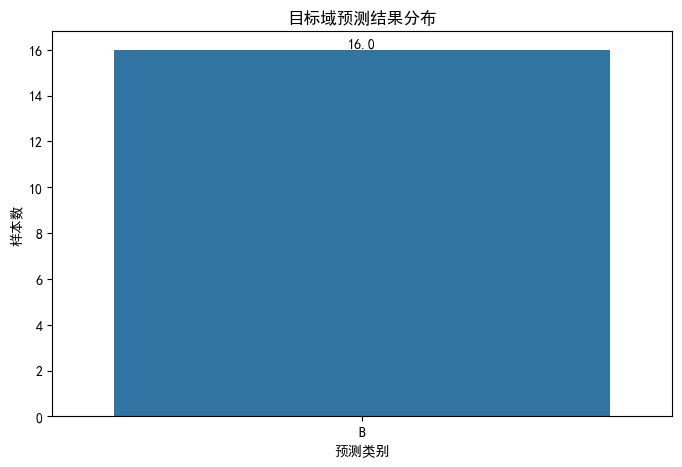

In [18]:
# 4. 在目标域上预测
y_tgt_pred = clf.predict(X_tgt_scaled)
y_tgt_proba = clf.predict_proba(X_tgt_scaled)

# 5. 可视化：预测分布

plt.figure(figsize=(8,5))
ax = sns.countplot(x=y_tgt_pred)

# 添加标签
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,   # 横坐标：柱子中心
            height,                        # 纵坐标：柱子顶端
            f'{height}',                   # 标签内容
            ha='center', va='bottom')      # 水平/垂直对齐方式

plt.title("目标域预测结果分布")
plt.xlabel("预测类别")
plt.ylabel("样本数")
plt.show()


  File "C:\Users\syczk\AppData\Roaming\Python\Python39\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "d:\download\Anaconda3\envs\DL\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\download\Anaconda3\envs\DL\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\download\Anaconda3\envs\DL\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


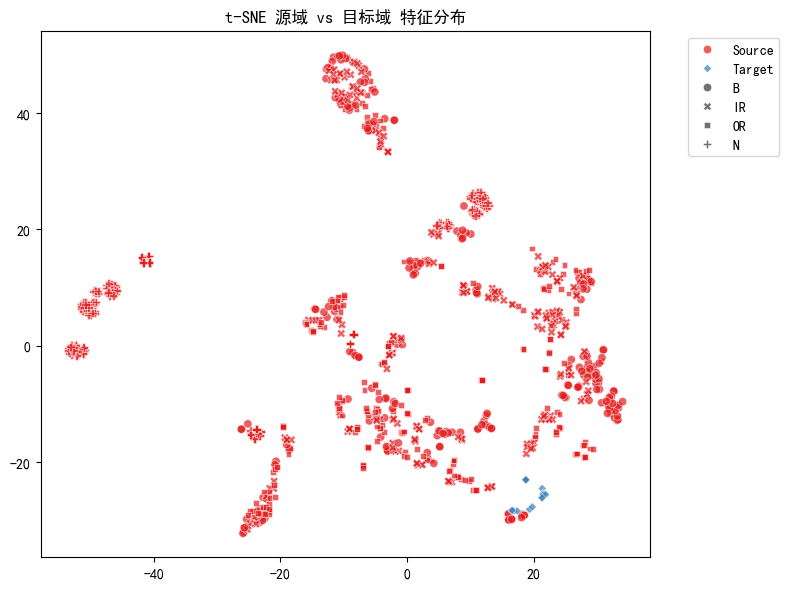

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import numpy as np

# ---------- 数据准备 ----------
# 源域特征 + 标签
X_src_scaled = scaler.transform(X_selected)
y_src = y_bal.values
src_labels = y_src

# 目标域特征
X_tgt_scaled = scaler.transform(X_tgt)
tgt_labels = np.array(["Target"]*len(X_tgt))  # 标签先统一标 "Target"

# 拼接源域 + 目标域
X_all = np.vstack([X_src_scaled, X_tgt_scaled])
domain_labels = np.array(["Source"]*len(X_src_scaled) + ["Target"]*len(X_tgt))
class_labels = np.concatenate([src_labels, tgt_labels])

# ---------- t-SNE 可视化 ----------
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_tsne = tsne.fit_transform(X_all)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=domain_labels,
                style=class_labels, palette="Set1", alpha=0.7)
plt.title("t-SNE 源域 vs 目标域 特征分布")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()



In [20]:
import numpy as np

def coral(source, target):
    # 计算协方差
    cov_s = np.cov(source, rowvar=False) + np.eye(source.shape[1])
    cov_t = np.cov(target, rowvar=False) + np.eye(target.shape[1])
    # 白化 + 重构
    U_s, S_s, _ = np.linalg.svd(cov_s)
    U_t, S_t, _ = np.linalg.svd(cov_t)
    A_s = U_s @ np.diag(S_s**-0.5) @ U_s.T
    A_t = U_t @ np.diag(S_t**0.5) @ U_t.T
    source_aligned = (source - source.mean(0)) @ A_s @ A_t + target.mean(0)
    return source_aligned

# 对源域特征进行 CORAL 变换
X_src_aligned = coral(X_src_scaled, X_tgt_scaled)

# 重新训练模型
clf_coral = RandomForestClassifier(random_state=42)
clf_coral.fit(X_src_aligned, y_bal)

# 在目标域预测
y_tgt_pred_coral = clf_coral.predict(X_tgt_scaled)


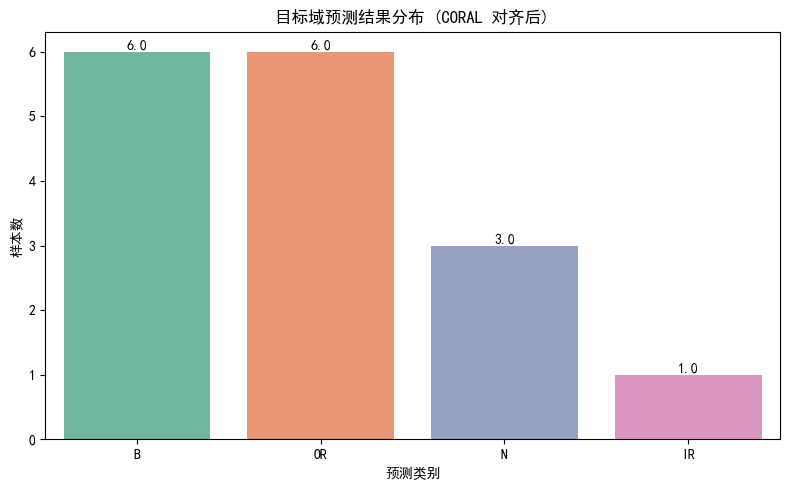

In [21]:
# ========== 5. 可视化：目标域预测分布（CORAL 对齐后） ==========

plt.figure(figsize=(8,5))
ax = sns.countplot(x=y_tgt_pred_coral, palette="Set2")

# 给每个柱子加上标签（样本数）
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, 
            height, 
            f'{height}', 
            ha='center', va='bottom', fontsize=10)

plt.title("目标域预测结果分布 (CORAL 对齐后)")
plt.xlabel("预测类别")
plt.ylabel("样本数")
plt.tight_layout()
plt.show()


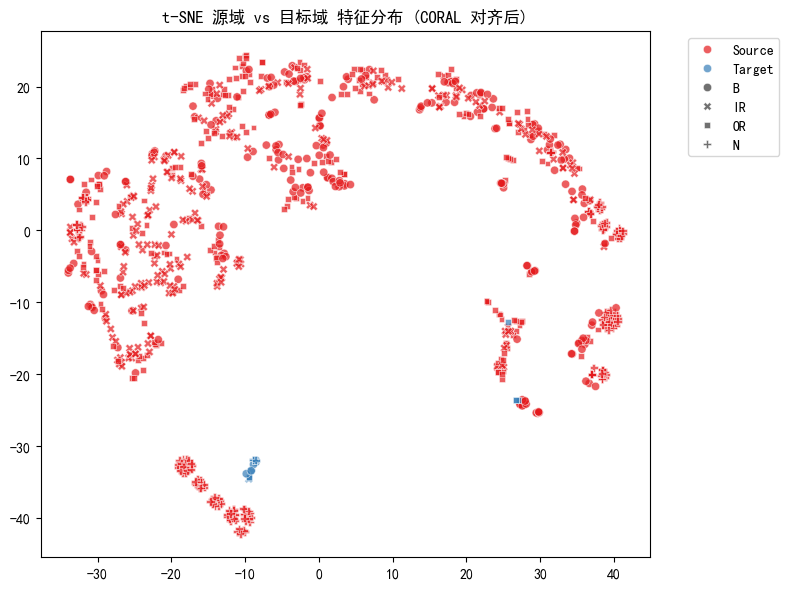

In [22]:
from sklearn.manifold import TSNE

# ========== 6. t-SNE 源域 vs 目标域 特征分布 (CORAL 对齐后) ==========

# 拼接源域 + 目标域特征
X_all = np.vstack([X_src_aligned, X_tgt_scaled])
domain_labels = np.array(["Source"]*len(X_src_aligned) + ["Target"]*len(X_tgt_scaled))
class_labels = np.concatenate([y_bal.values, y_tgt_pred_coral])

# t-SNE 降维
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_tsne = tsne.fit_transform(X_all)

# 绘制分布图
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], 
                hue=domain_labels, style=class_labels,
                palette="Set1", alpha=0.7)

plt.title("t-SNE 源域 vs 目标域 特征分布 (CORAL 对齐后)")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


In [23]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# ========== 7. 目标域聚类一致性评价 (KMeans / GMM) ==========

# 模型预测的标签
y_pred = y_tgt_pred_coral

# ---------- KMeans ----------
kmeans = KMeans(n_clusters=len(np.unique(y_pred)), random_state=42)
y_kmeans = kmeans.fit_predict(X_tgt_scaled)


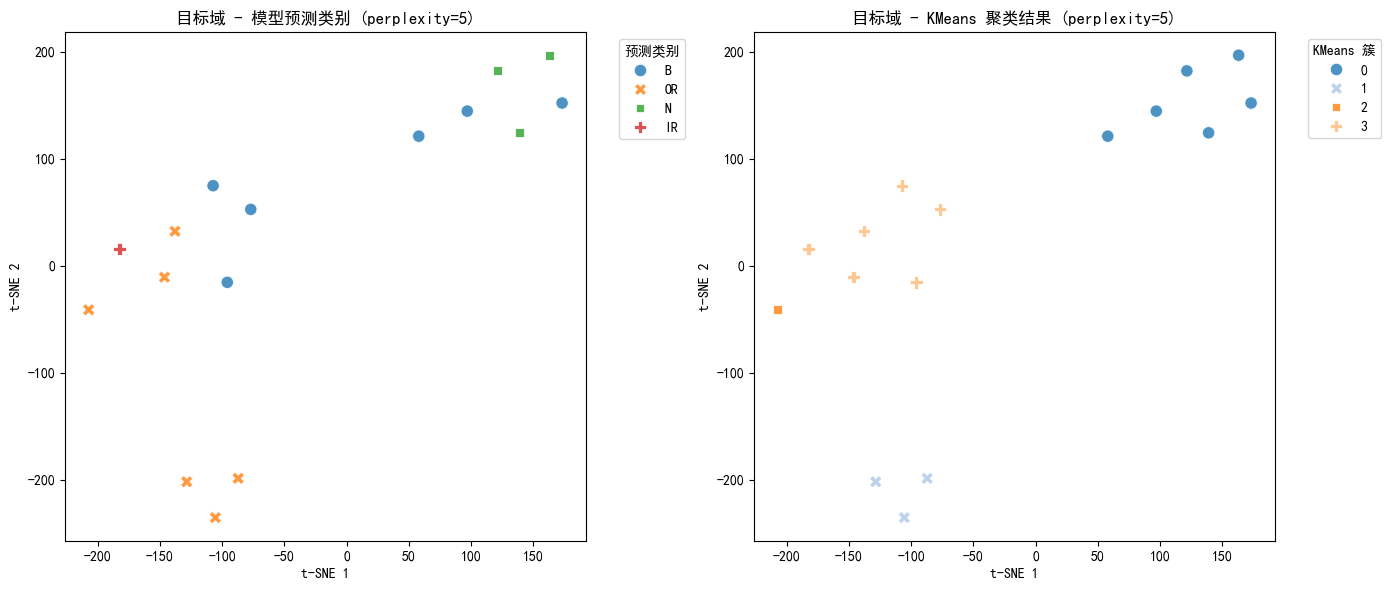

In [24]:
from sklearn.manifold import TSNE

# ---------- t-SNE 降维 ----------
n_samples = X_tgt_scaled.shape[0]
perplexity = max(1, min(30, n_samples // 3))  # 让 perplexity 在合理范围内

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, learning_rate=200)
X_tgt_tsne = tsne.fit_transform(X_tgt_scaled)

plt.figure(figsize=(14,6))

# -------- 子图1：模型预测类别 --------
plt.subplot(1,2,1)
sns.scatterplot(x=X_tgt_tsne[:,0], y=X_tgt_tsne[:,1],
                hue=y_tgt_pred_coral, style=y_tgt_pred_coral,
                palette="tab10", alpha=0.8, s=80)  # s 控制点大小
plt.title(f"目标域 - 模型预测类别 (perplexity={perplexity})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", title="预测类别")

# -------- 子图2：KMeans 聚类结果 --------
plt.subplot(1,2,2)
sns.scatterplot(x=X_tgt_tsne[:,0], y=X_tgt_tsne[:,1],
                hue=y_kmeans, style=y_kmeans,
                palette="tab20", alpha=0.8, s=80)
plt.title(f"目标域 - KMeans 聚类结果 (perplexity={perplexity})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", title="KMeans 簇")

plt.tight_layout()
plt.show()


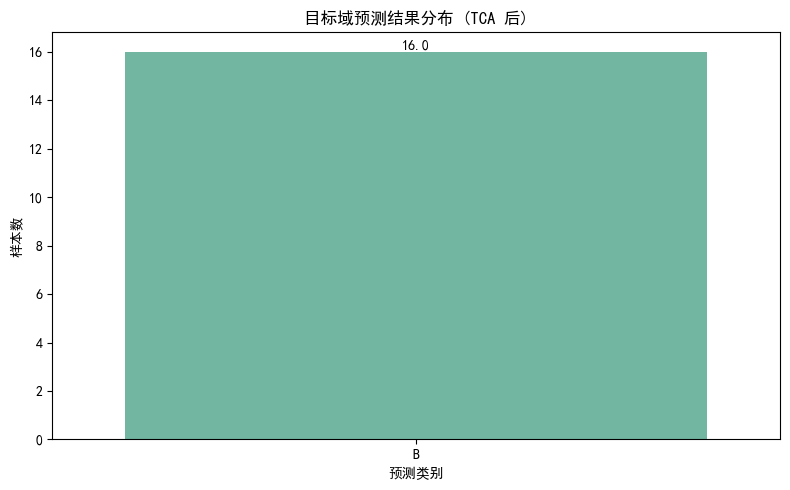

In [25]:
import numpy as np
from numpy.linalg import eigh
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1) 准备数据（承接你已有变量）
#   - X_selected, y_bal ：源域特征（RFE 后）
#   - X_tgt            ：目标域特征（列与 X_selected 对齐）
#   - 建议先用源域拟合 scaler，再共同变换
# ------------------------------------------------------------
scaler = StandardScaler()
scaler.fit(X_selected.values)                 # 用源域拟合
Xs = scaler.transform(X_selected.values)      # 源域
Xt = scaler.transform(X_tgt.values)           # 目标域
ys = y_bal.values                             # 源域标签
ns, nt = Xs.shape[0], Xt.shape[0]

# ------------------------------------------------------------
# 2) TCA 实现（线性/核 TCA）
#   参考公式：解广义特征问题 (K L K + mu I) A = K H K A Λ
#   Z = A^T K -> [Zs, Zt]
# ------------------------------------------------------------
def _kernel(X1, X2=None, kernel='rbf', gamma=None):
    X2 = X1 if X2 is None else X2
    if kernel == 'linear':
        return X1 @ X2.T
    if gamma is None:
        # 常用启发式：1 / (特征数)
        gamma = 1.0 / X1.shape[1]
    # RBF
    X1_sq = np.sum(X1**2, axis=1, keepdims=True)
    X2_sq = np.sum(X2**2, axis=1, keepdims=True).T
    dist2 = X1_sq + X2_sq - 2 * (X1 @ X2.T)
    return np.exp(-gamma * dist2)

def TCA(Xs, Xt, dim=20, mu=1.0, kernel='rbf', gamma=None):
    """
    Xs: 源域 (ns, d)
    Xt: 目标 (nt, d)
    返回 Zs, Zt （投影后）
    """
    X = np.vstack([Xs, Xt])                   # (n, d)
    n = X.shape[0]
    ns = Xs.shape[0]
    nt = Xt.shape[0]

    # MMD 矩阵 L
    e = np.vstack([
        np.full((ns,1),  1.0/ns),
        np.full((nt,1), -1.0/nt)
    ])
    L = e @ e.T                               # (n, n)

    # 中心化矩阵 H
    H = np.eye(n) - np.ones((n,n)) / n

    # 核矩阵 K
    K = _kernel(X, kernel=kernel, gamma=gamma)

    # 广义特征问题：(K L K + mu I) A = K H K A Λ
    KLK = K @ L @ K
    KHK = K @ H @ K
    A_mat = KLK + mu * np.eye(n)

    # eigh 解对称广义特征问题 A v = λ B v
    # 这里用 np.linalg.eigh(A) 近似：将 B^{-1} A 作为对称矩阵（数值更稳可加小正则）
    # 简化做法：对 A^{-1} KHK 做特征分解
    # 为稳健起见，先做个小的 Tikhonov 正则
    reg = 1e-6
    A_inv = np.linalg.pinv(A_mat + reg*np.eye(n))
    M = A_inv @ KHK

    eigvals, eigvecs = eigh(M)
    idx = np.argsort(eigvals)[::-1]          # 取最大几个特征值对应向量
    A = eigvecs[:, idx[:dim]]                # (n, dim)

    Z = A.T @ K                               # (dim, n)
    Zs = Z[:, :ns].T
    Zt = Z[:, ns:].T
    return Zs, Zt

# ------------------------------------------------------------
# 3) 执行 TCA：得到公共子空间特征
# ------------------------------------------------------------
Zs, Zt = TCA(Xs, Xt, dim=min(20, Xs.shape[1]), mu=1.0, kernel='rbf', gamma=None)

# ------------------------------------------------------------
# 4) 用源域(投影后)训练分类器，在目标域(投影后)做预测
# ------------------------------------------------------------
clf_tca = RandomForestClassifier(random_state=42)
clf_tca.fit(Zs, ys)
y_tgt_pred_tca = clf_tca.predict(Zt)
y_tgt_proba_tca = clf_tca.predict_proba(Zt)

# 可视化：目标域预测分布
plt.figure(figsize=(8,5))
ax = sns.countplot(x=y_tgt_pred_tca, palette="Set2")
for p in ax.patches:
    h = p.get_height()
    ax.text(p.get_x()+p.get_width()/2, h, f'{h}', ha='center', va='bottom')
plt.title("目标域预测结果分布 (TCA 后)")
plt.xlabel("预测类别")
plt.ylabel("样本数")
plt.tight_layout()
plt.show()


TCA 目标域聚类一致性：NMI=0.000  ARI=0.000


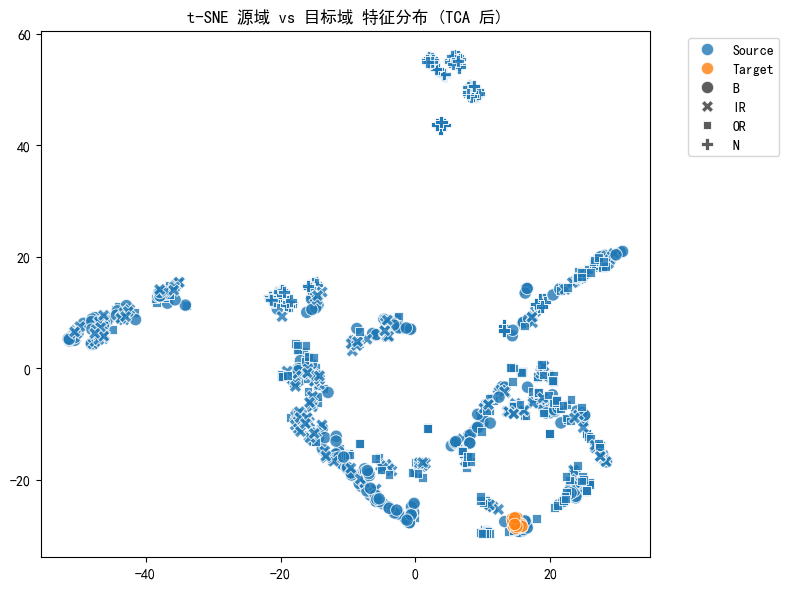

In [26]:

# ------------------------------------------------------------
# 5) 一致性评价：KMeans 聚类 vs 模型预测（目标域）
# ------------------------------------------------------------
kmeans = KMeans(n_clusters=len(np.unique(ys)), random_state=42)
y_kmeans_tca = kmeans.fit_predict(Zt)

nmi_tca = normalized_mutual_info_score(y_tgt_pred_tca, y_kmeans_tca)
ari_tca = adjusted_rand_score(y_tgt_pred_tca, y_kmeans_tca)
print(f"TCA 目标域聚类一致性：NMI={nmi_tca:.3f}  ARI={ari_tca:.3f}")

# ------------------------------------------------------------
# 6) t-SNE 可视化：源域 vs 目标域（TCA 后）
# ------------------------------------------------------------
X_all_tca = np.vstack([Zs, Zt])
domain_labels = np.array(["Source"]*Zs.shape[0] + ["Target"]*Zt.shape[0])
class_labels  = np.concatenate([ys, y_tgt_pred_tca])

perplexity = max(5, min(30, X_all_tca.shape[0]//3))
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, learning_rate=200)
X_tsne_tca = tsne.fit_transform(X_all_tca)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne_tca[:,0], y=X_tsne_tca[:,1],
                hue=domain_labels, style=class_labels,
                palette="tab10", alpha=0.8, s=80)
plt.title("t-SNE 源域 vs 目标域 特征分布 (TCA 后)")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


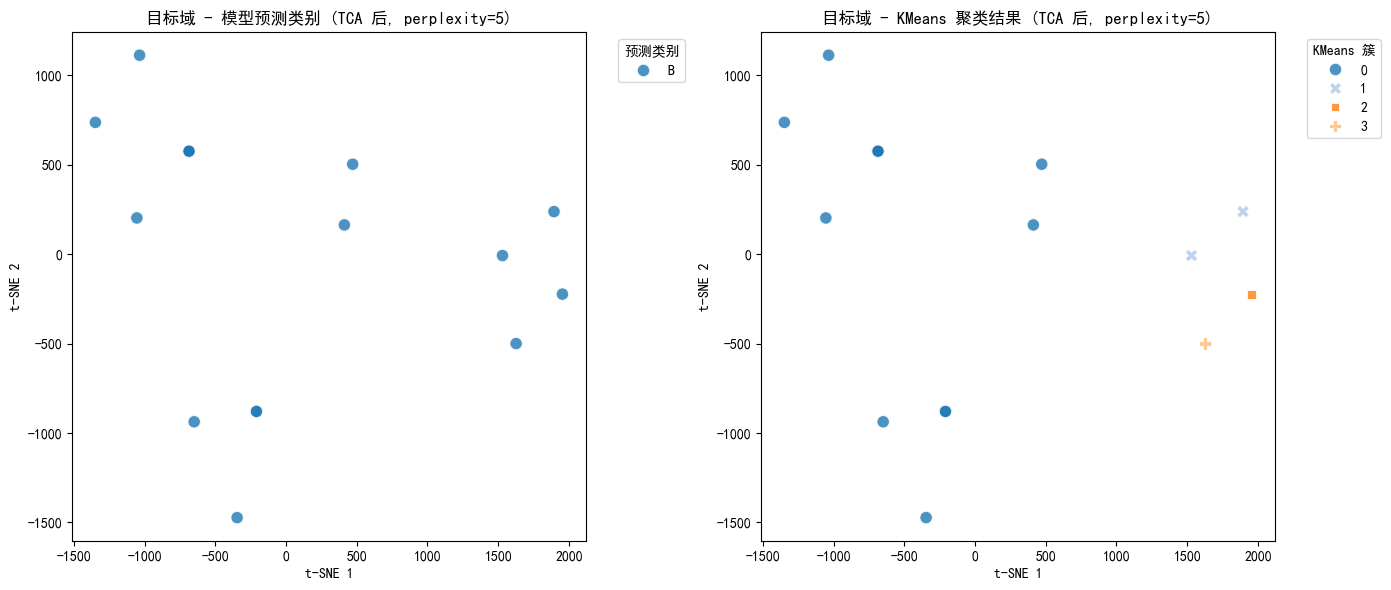

In [27]:
# ========== t-SNE 目标域 (TCA 后) ==========

n_samples_tca = Zt.shape[0]
perplexity_tca = max(1, min(30, n_samples_tca // 3))

tsne_tca = TSNE(n_components=2, random_state=42, perplexity=perplexity_tca, learning_rate=200)
X_tgt_tsne_tca = tsne_tca.fit_transform(Zt)

plt.figure(figsize=(14,6))

# -------- 子图1：模型预测类别 (TCA 后) --------
plt.subplot(1,2,1)
sns.scatterplot(x=X_tgt_tsne_tca[:,0], y=X_tgt_tsne_tca[:,1],
                hue=y_tgt_pred_tca, style=y_tgt_pred_tca,
                palette="tab10", alpha=0.8, s=80)
plt.title(f"目标域 - 模型预测类别 (TCA 后, perplexity={perplexity_tca})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", title="预测类别")

# -------- 子图2：KMeans 聚类结果 (TCA 后) --------
plt.subplot(1,2,2)
sns.scatterplot(x=X_tgt_tsne_tca[:,0], y=X_tgt_tsne_tca[:,1],
                hue=y_kmeans_tca, style=y_kmeans_tca,
                palette="tab20", alpha=0.8, s=80)
plt.title(f"目标域 - KMeans 聚类结果 (TCA 后, perplexity={perplexity_tca})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", title="KMeans 簇")

plt.tight_layout()
plt.show()


In [28]:

# 转换为 DataFrame，保持列名
X_src_df = pd.DataFrame(X_src_scaled, index=X_selected.index, columns=X_selected.columns)
X_tgt_df = pd.DataFrame(X_tgt_scaled, index=X_tgt.index, columns=X_tgt.columns)

# 目标域 min/max
tgt_min = X_tgt_df.min(axis=0)
tgt_max = X_tgt_df.max(axis=0)

# 判断每个特征是否在范围内
satisfy_matrix = (X_src_df >= tgt_min) & (X_src_df <= tgt_max)

# 每个样本满足的特征数量
satisfy_count = satisfy_matrix.sum(axis=1)

# 阈值：至少满足 % 特征
threshold = int(0.2 * X_src_df.shape[1])
mask = satisfy_count >= threshold

# 筛选后的源域样本
X_src_filtered = X_src_df[mask].reset_index(drop=True)
y_src_filtered = y_bal[mask].reset_index(drop=True)

print("原始源域样本数:", len(X_src_df))
print("筛选后源域样本数:", len(X_src_filtered))
print("平均满足特征数:", satisfy_count.mean())
print("筛选阈值 (至少特征数):", threshold)


原始源域样本数: 847
筛选后源域样本数: 778
平均满足特征数: 7.696576151121605
筛选阈值 (至少特征数): 4


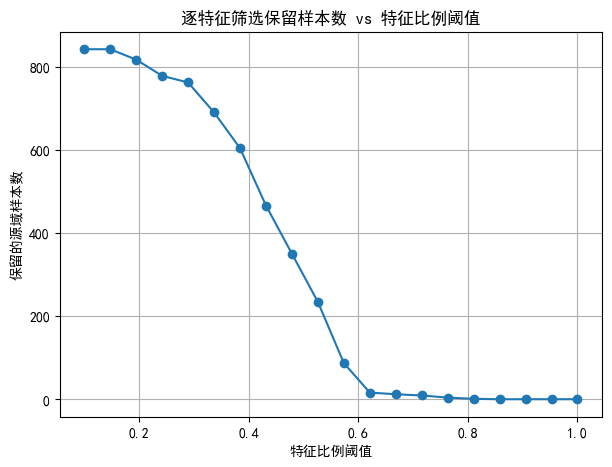

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 满足特征数统计
satisfy_count = ((X_src_df >= tgt_min) & (X_src_df <= tgt_max)).sum(axis=1)
n_features = X_src_df.shape[1]

# 逐比例计算能保留的样本数
ratios = np.linspace(0.1, 1.0, 20)   # 从50%到100%，步长0.05
kept_counts = []

for r in ratios:
    threshold = int(r * n_features)
    kept = (satisfy_count >= threshold).sum()
    kept_counts.append(kept)

# 绘制曲线
plt.figure(figsize=(7,5))
plt.plot(ratios, kept_counts, marker="o")
plt.title("逐特征筛选保留样本数 vs 特征比例阈值")
plt.xlabel("特征比例阈值")
plt.ylabel("保留的源域样本数")
plt.grid(True)
plt.show()


In [30]:

# 转换为 DataFrame，保持列名
X_src_df = pd.DataFrame(X_src_scaled, index=X_selected.index, columns=X_selected.columns)
X_tgt_df = pd.DataFrame(X_tgt_scaled, index=X_tgt.index, columns=X_tgt.columns)

# 目标域 min/max
tgt_min = X_tgt_df.min(axis=0)
tgt_max = X_tgt_df.max(axis=0)

# 判断每个特征是否在范围内
satisfy_matrix = (X_src_df >= tgt_min) & (X_src_df <= tgt_max)

# 每个样本满足的特征数量
satisfy_count = satisfy_matrix.sum(axis=1)

# 阈值：至少满足 80% 特征
threshold = int(0.2 * X_src_df.shape[1])
mask = satisfy_count >= threshold

# 筛选后的源域样本
X_src_filtered = X_src_df[mask].reset_index(drop=True)
y_src_filtered = y_bal[mask].reset_index(drop=True)

print("原始源域样本数:", len(X_src_df))
print("筛选后源域样本数:", len(X_src_filtered))
print("平均满足特征数:", satisfy_count.mean())
print("筛选阈值 (至少特征数):", threshold)


原始源域样本数: 847
筛选后源域样本数: 778
平均满足特征数: 7.696576151121605
筛选阈值 (至少特征数): 4


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize

# ========== 数据划分 ==========
X_train, X_test, y_train, y_test = train_test_split(
    X_src_filtered, y_src_filtered, test_size=0.3, random_state=42, stratify=y_src_filtered
)

# ========== 构建分类器 ==========
# ========== 构建分类器 ==========
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)

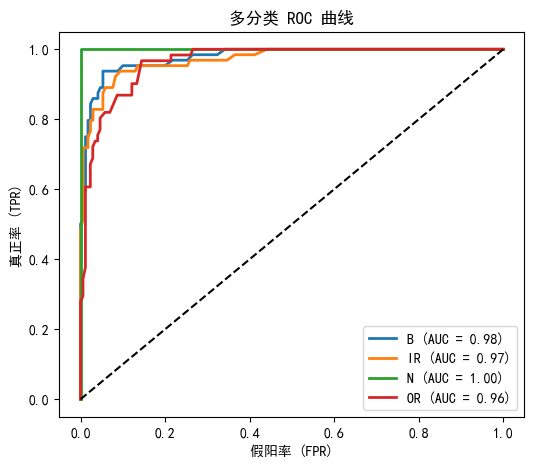

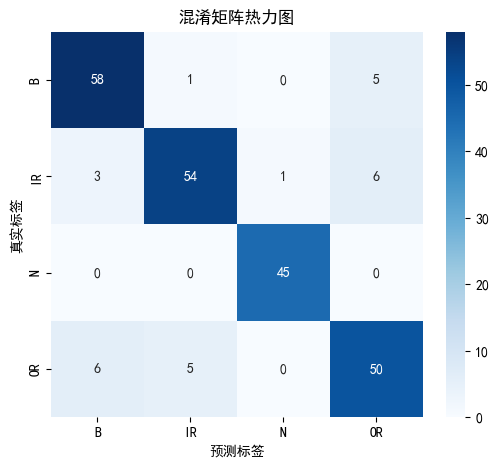

F1 分类报告：
              precision    recall  f1-score   support

           B       0.87      0.91      0.89        64
          IR       0.90      0.84      0.87        64
           N       0.98      1.00      0.99        45
          OR       0.82      0.82      0.82        61

    accuracy                           0.88       234
   macro avg       0.89      0.89      0.89       234
weighted avg       0.88      0.88      0.88       234



In [32]:
# ========== 1. ROC曲线 ==========
classes = np.unique(y_bal)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(6,5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("假阳率 (FPR)")
plt.ylabel("真正率 (TPR)")
plt.title("多分类 ROC 曲线")
plt.legend(loc="lower right")
plt.show()

# ========== 2. 混淆矩阵 ==========
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("预测标签")
plt.ylabel("真实标签")
plt.title("混淆矩阵热力图")
plt.show()

# ========== 3. F1 报告 ==========
print("F1 分类报告：")
print(classification_report(y_test, y_pred, target_names=classes))

In [33]:
# ====================== PSO 超参数寻优（不使用交叉验证）======================
# 思路：
# - 在 (X_train, y_train) 内再划一份验证集 (X_tr, X_val) 做单次 holdout；
# - 用 PSO 搜索随机森林的超参数，使得在验证集上的 F1_macro 得分最大；
# - 取得最优超参数后，在 (X_train)（即训练+验证合并）上重训，再到 X_test 上评估。

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import math
import time

# ---------- 1) 训练/验证划分（非交叉验证，仅一次性切分） ----------
X_tr, X_val, y_tr, y_val =X_train, X_test, y_train, y_test

# ---------- 2) 定义搜索空间 ----------
# 连续空间 -> 训练时取整（对整数超参），或直接用浮点（如 max_features 的比例）
SPACE = {
    "n_estimators": (50, 1000),       # 整数
    "max_depth":   (3, 50),          # 整数（不考虑 None，如需可放宽到[0,30]，0代表None）
    "min_samples_split": (2, 20),    # 整数
    "min_samples_leaf":  (1, 20)    # 整数

}

def decode_particle(vec):
    """将粒子实数向量映射为随机森林超参数字典"""
    (ne_lo, ne_hi) = SPACE["n_estimators"]
    (md_lo, md_hi) = SPACE["max_depth"]
    (mss_lo, mss_hi) = SPACE["min_samples_split"]
    (msl_lo, msl_hi) = SPACE["min_samples_leaf"]

    params = {
        "n_estimators": int(round(np.clip(vec[0], ne_lo, ne_hi))),
        "max_depth":    int(round(np.clip(vec[1], md_lo, md_hi))),
        "min_samples_split": int(round(np.clip(vec[2], mss_lo, mss_hi))),
        "min_samples_leaf":  int(round(np.clip(vec[3], msl_lo, msl_hi))),
        "random_state": 42,
        "n_jobs": -1,
    }
    # 边界条件修正（避免非法组合）
    params["min_samples_split"] = max(params["min_samples_split"], params["min_samples_leaf"]+0)  # split>=leaf 通常更稳
    return params

def evaluate_particle(vec):
    """以验证集 F1_macro 为目标函数（越大越好）"""
    params = decode_particle(vec)
    clf_pso = RandomForestClassifier(**params)
    clf_pso.fit(X_tr, y_tr)
    pred_val = clf_pso.predict(X_val)
    f1 = f1_score(y_val, pred_val, average="macro")
    return f1

# ---------- 3) PSO 主过程 ----------
# PSO 参数
NUM_DIM = 4
NUM_PARTICLES = 20
NUM_ITERS = 25
W = 0.72          # 惯性权重
C1 = 1.49         # 个体学习因子
C2 = 1.49         # 群体学习因子
rng = np.random.default_rng(2025)

# 初始化粒子（在每一维的空间范围内均匀随机）
LOWS  = np.array([SPACE["n_estimators"][0], SPACE["max_depth"][0], SPACE["min_samples_split"][0], SPACE["min_samples_leaf"][0]])
HIGHS = np.array([SPACE["n_estimators"][1], SPACE["max_depth"][1], SPACE["min_samples_split"][1], SPACE["min_samples_leaf"][1]])

positions = rng.uniform(LOWS, HIGHS, size=(NUM_PARTICLES, NUM_DIM))
velocities = rng.uniform(-np.abs(HIGHS-LOWS), np.abs(HIGHS-LOWS), size=(NUM_PARTICLES, NUM_DIM))*0.1

# 评估初值
pbest_pos = positions.copy()
pbest_val = np.array([evaluate_particle(p) for p in positions])

gbest_idx = int(np.argmax(pbest_val))
gbest_pos = pbest_pos[gbest_idx].copy()
gbest_val = float(pbest_val[gbest_idx])

print(f"[PSO] 初始最优 F1_macro = {gbest_val:.4f}，超参数 = {decode_particle(gbest_pos)}")

t0 = time.time()
for it in range(1, NUM_ITERS+1):
    # 更新速度与位置
    r1 = rng.random((NUM_PARTICLES, NUM_DIM))
    r2 = rng.random((NUM_PARTICLES, NUM_DIM))
    velocities = (
        W*velocities
        + C1*r1*(pbest_pos - positions)
        + C2*r2*(gbest_pos - positions)
    )
    positions = positions + velocities
    # 位置边界裁剪
    positions = np.minimum(np.maximum(positions, LOWS), HIGHS)

    # 评估
    vals = np.array([evaluate_particle(p) for p in positions])

    # 更新个体最优
    improved = vals > pbest_val
    pbest_pos[improved] = positions[improved]
    pbest_val[improved] = vals[improved]

    # 更新全局最优
    if pbest_val.max() > gbest_val:
        gbest_idx = int(np.argmax(pbest_val))
        gbest_pos = pbest_pos[gbest_idx].copy()
        gbest_val = float(pbest_val[gbest_idx])

    if it % 5 == 0 or it == NUM_ITERS:
        print(f"[PSO] 迭代 {it:02d}/{NUM_ITERS}，当前最优 F1_macro = {gbest_val:.4f}")

t1 = time.time()
print(f"[PSO] 完成。耗时 {t1 - t0:.1f}s")
best_params = decode_particle(gbest_pos)
print("[PSO] 最优超参数：", best_params)

# ---------- 4) 用最优超参数在训练集（X_train，全量）上重训，并在测试集评估 ----------
clf_best = RandomForestClassifier(**best_params)
clf_best.fit(X_train, y_train)

y_pred_best = clf_best.predict(X_test)
y_proba_best = clf_best.predict_proba(X_test)

f1_macro_test = f1_score(y_test, y_pred_best, average="macro")
print(f"[PSO] 最优模型在测试集上的 F1_macro：{f1_macro_test:.4f}")




[PSO] 初始最优 F1_macro = 0.8795，超参数 = {'n_estimators': 846, 'max_depth': 34, 'min_samples_split': 3, 'min_samples_leaf': 3, 'random_state': 42, 'n_jobs': -1}
[PSO] 迭代 05/25，当前最优 F1_macro = 0.9035
[PSO] 迭代 10/25，当前最优 F1_macro = 0.9035
[PSO] 迭代 15/25，当前最优 F1_macro = 0.9035
[PSO] 迭代 20/25，当前最优 F1_macro = 0.9035
[PSO] 迭代 25/25，当前最优 F1_macro = 0.9035
[PSO] 完成。耗时 419.4s
[PSO] 最优超参数： {'n_estimators': 605, 'max_depth': 21, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1}
[PSO] 最优模型在测试集上的 F1_macro：0.9035


In [34]:
clf = RandomForestClassifier(**  {'n_estimators': 581, 'max_depth': 38, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1})
clf.fit(X_src_filtered, y_src_filtered)

RandomForestClassifier(max_depth=38, n_estimators=581, n_jobs=-1,
                       random_state=42)

In [35]:
X_selected.columns

Index(['标准差', '方差', '均方根', '峰值', '峰峰值', '平均绝对值', '波形指标', '峭度指标', '裕度指标', '峭度',
       '谱质心', '谱峭度', '带通能量_4', '时频熵', '时频均值频率', '小波能量_0', '小波能量_1', '小波能量_2',
       '小波能量_3', '小波能量_4'],
      dtype='object')

In [36]:
import numpy as np

def coral(Xs, Xt):
    """
    CORAL: CORrelation ALignment
    输入:
        Xs : 源域特征 (numpy array 或 DataFrame)
        Xt : 目标域特征 (numpy array 或 DataFrame)
    输出:
        Xs_new : 对齐后的源域特征
    """
    # 转换为 numpy
    if isinstance(Xs, pd.DataFrame):
        Xs_ = Xs.values
    else:
        Xs_ = Xs
    if isinstance(Xt, pd.DataFrame):
        Xt_ = Xt.values
    else:
        Xt_ = Xt

    # 计算协方差矩阵
    cov_src = np.cov(Xs_, rowvar=False) + np.eye(Xs_.shape[1])
    cov_tar = np.cov(Xt_, rowvar=False) + np.eye(Xt_.shape[1])

    # 矩阵开方 & 逆开方
    cov_src_inv_sqrt = np.linalg.inv(np.real(np.linalg.cholesky(cov_src)))
    cov_tar_sqrt = np.real(np.linalg.cholesky(cov_tar))

    # 变换
    Xs_aligned = (Xs_ - np.mean(Xs_, axis=0)) @ cov_src_inv_sqrt @ cov_tar_sqrt + np.mean(Xt_, axis=0)

    return Xs_aligned

# ---------- 应用 ----------
# 源域经过 CORAL 对齐
X_src_coral = coral(X_src_filtered, X_tgt_scaled)

print("源域原始形状:", X_src_filtered.shape)
print("源域 CORAL 对齐后形状:", X_src_coral.shape)


源域原始形状: (778, 20)
源域 CORAL 对齐后形状: (778, 20)


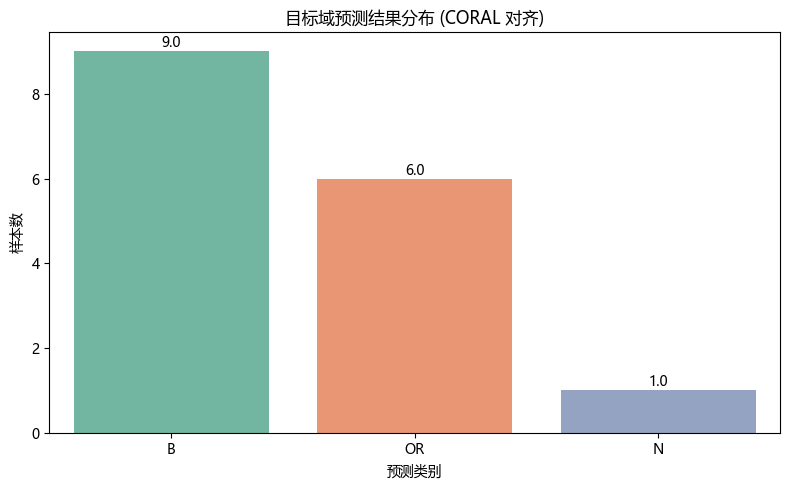

目标域预测结果前20个：
['B' 'B' 'B' 'OR' 'B' 'OR' 'B' 'B' 'B' 'B' 'OR' 'OR' 'B' 'N' 'OR' 'OR']


In [62]:
# ========== 1. 用 CORAL 对齐后的源域特征重新训练 ==========
clf_coral = RandomForestClassifier(
    **{'n_estimators': 581, 'max_depth': 38, 'min_samples_split': 2,
       'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1}
)

clf_coral.fit(X_src_coral, y_src_filtered)

# ========== 2. 在目标域上预测 ==========
y_tgt_pred_coral = clf_coral.predict(X_tgt_scaled)
y_tgt_pred_proba_coral = clf_coral.predict_proba(X_tgt_scaled)

# ========== 3. 查看预测结果分布 ==========
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
ax = sns.countplot(x=y_tgt_pred_coral, palette="Set2")

# 添加标签
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,
            height,
            f'{height}',
            ha='center', va='bottom')

plt.title("目标域预测结果分布 (CORAL 对齐)")
plt.xlabel("预测类别")
plt.ylabel("样本数")
plt.tight_layout()
plt.show()

# ========== 4. 打印部分预测结果 ==========
print("目标域预测结果前20个：")
print(y_tgt_pred_coral[:20])


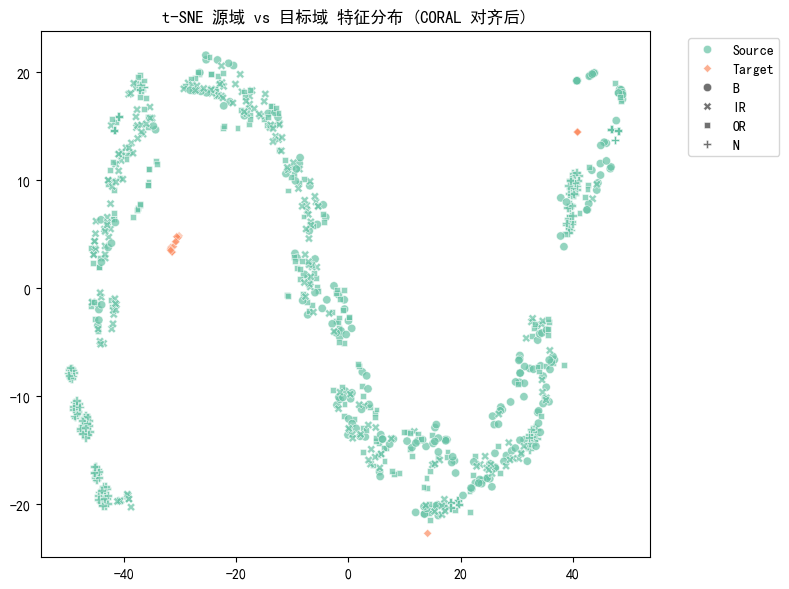

In [38]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------- 数据准备 ----------
# 源域（CORAL 后）
X_src_coral_df = pd.DataFrame(X_src_coral, index=X_src_filtered.index, columns=X_src_filtered.columns)

# 拼接源域 + 目标域
X_all_coral = np.vstack([X_src_coral_df.values, X_tgt_scaled])
domain_labels_coral = np.array(["Source"]*len(X_src_coral_df) + ["Target"]*len(X_tgt_scaled))
class_labels_coral = np.concatenate([y_src_filtered.values, ["Target"]*len(X_tgt_scaled)])

# ---------- t-SNE ----------
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_tsne_coral = tsne.fit_transform(X_all_coral)

# ---------- 绘图 ----------
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne_coral[:,0], y=X_tsne_coral[:,1],
                hue=domain_labels_coral, style=class_labels_coral,
                palette="Set2", alpha=0.7)

plt.title("t-SNE 源域 vs 目标域 特征分布 (CORAL 对齐后)")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


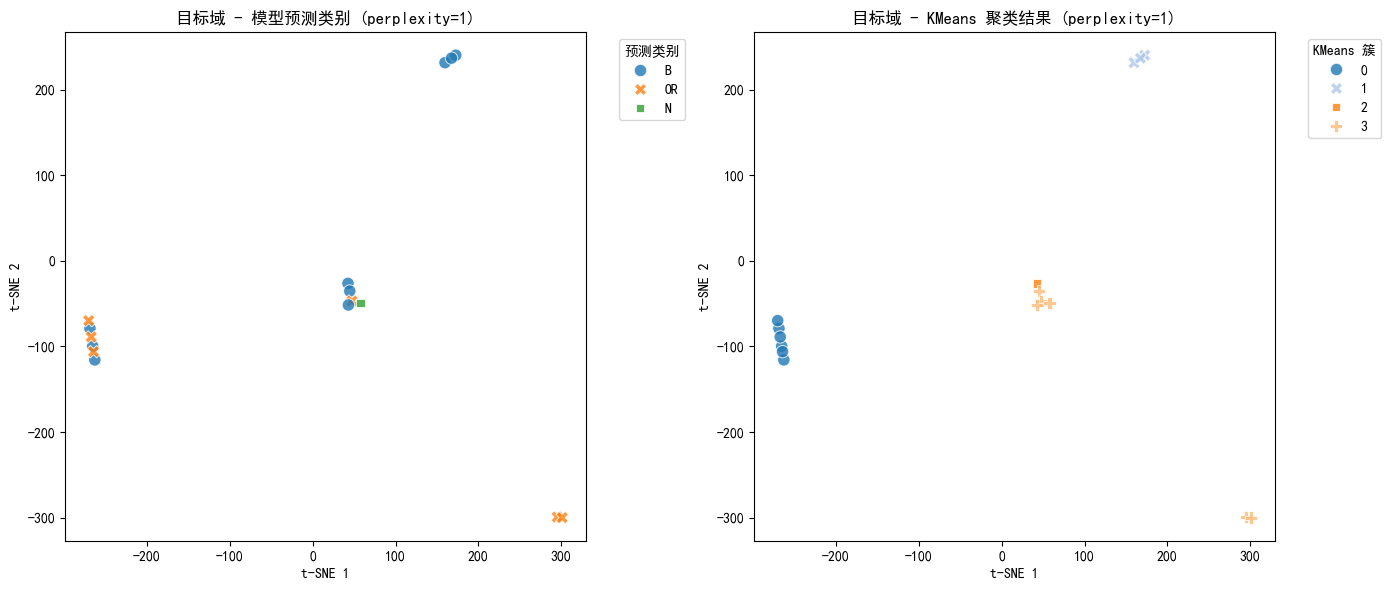

In [39]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- t-SNE 降维 ----------
n_samples = X_tgt_scaled.shape[0]
perplexity =1

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, learning_rate=200)
X_tgt_tsne = tsne.fit_transform(X_tgt_scaled)

# ---------- KMeans 聚类 ----------
n_clusters = len(np.unique(y_src_filtered))  # 源域的类别数
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_tgt_scaled)

# ---------- 绘图 ----------
plt.figure(figsize=(14,6))

# 子图1：模型预测类别
plt.subplot(1,2,1)
sns.scatterplot(x=X_tgt_tsne[:,0], y=X_tgt_tsne[:,1],
                hue=y_tgt_pred_coral, style=y_tgt_pred_coral,
                palette="tab10", alpha=0.8, s=80)
plt.title(f"目标域 - 模型预测类别 (perplexity={perplexity})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", title="预测类别")

# 子图2：KMeans 聚类结果
plt.subplot(1,2,2)
sns.scatterplot(x=X_tgt_tsne[:,0], y=X_tgt_tsne[:,1],
                hue=y_kmeans, style=y_kmeans,
                palette="tab20", alpha=0.8, s=80)
plt.title(f"目标域 - KMeans 聚类结果 (perplexity={perplexity})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", title="KMeans 簇")

plt.tight_layout()
plt.show()


### 问题4:

In [40]:
X_src_df

,标准差,方差,均方根,峰值,峰峰值,平均绝对值,波形指标,峭度指标,裕度指标,峭度,谱质心,谱峭度,带通能量_4,时频熵,时频均值频率,小波能量_0,小波能量_1,小波能量_2,小波能量_3,小波能量_4
0,-0.242250,-0.192780,-0.242251,-0.423034,-0.422320,-0.179084,-0.700513,-0.584180,-0.671248,-0.531296,-0.379735,-0.830970,-0.303723,-0.910494,-0.380363,-0.703689,-0.696310,1.980242,-0.593497,-1.230208
1,-0.237886,-0.192062,-0.237888,-0.399566,-0.389878,-0.172586,-0.716201,-0.517587,-0.629113,-0.532398,-0.377613,-0.729191,-0.204284,-0.946857,-0.378195,-0.802350,-0.813323,2.064241,-0.501263,-1.229301
2,-0.202249,-0.185988,-0.202251,-0.423529,-0.422035,-0.128082,-0.744310,-0.662892,-0.731211,-0.551313,-0.375822,-0.460353,-0.340842,-1.076533,-0.376408,-0.849357,-0.775293,2.017989,-0.381375,-1.228016
3,-0.175071,-0.181109,-0.175073,-0.367266,-0.362293,-0.097089,-0.733705,-0.546565,-0.651475,-0.542729,-0.377293,-0.340479,-0.184503,-0.991364,-0.377860,-0.772746,-0.430520,1.885460,-0.597917,-1.230244
4,-0.202212,-0.185982,-0.202214,0.587432,0.567900,-0.261598,0.992073,2.400030,2.240217,2.531339,-0.385180,-0.795722,-0.338568,-1.461017,-0.385753,-0.189403,-0.484306,1.731690,-1.023681,-1.234602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,-0.435565,-0.219085,-0.435567,-0.530157,-0.527733,-0.406327,-0.689049,-0.505287,-0.618378,-0.491904,-0.335665,0.441620,-0.028655,0.878155,-0.336073,0.765994,-0.238429,-0.817072,-0.204062,0.759878
227,0.003632,-0.143712,0.003630,-0.427122,-0.415882,0.003251,0.251029,-0.947891,-0.761789,-0.496860,-0.317151,2.417482,-0.381704,-0.000668,-0.317567,-0.877970,-0.661538,0.059488,0.731266,0.755227
228,0.144940,-0.107602,0.144938,-0.353795,-0.341579,0.159910,0.170562,-0.926235,-0.755796,-0.513947,-0.319936,1.960857,-0.437068,-0.016672,-0.320593,-0.842863,-0.713834,0.069198,0.703469,0.766785
229,0.350301,-0.044833,0.350298,-0.286812,-0.277907,0.486163,-0.532882,-0.966963,-0.907308,-0.575029,-0.316889,1.928040,-0.441659,-0.110640,-0.317409,-0.881108,-0.723200,0.080943,0.741023,0.768126


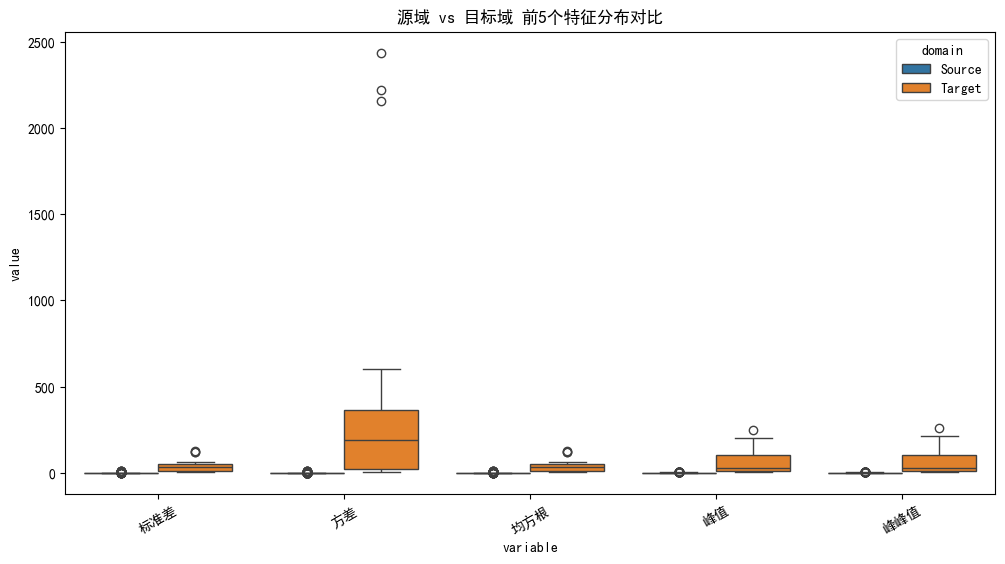

源域 vs 目标域 特征均值差异最大的前10个特征：
方差        555.599786
峰峰值        66.228908
峰值         63.932797
标准差        45.405815
均方根        45.405738
平均绝对值      41.436148
小波能量_3      2.112221
小波能量_2      1.178874
小波能量_4      1.098093
峭度          1.003733
Name: mean, dtype: float64


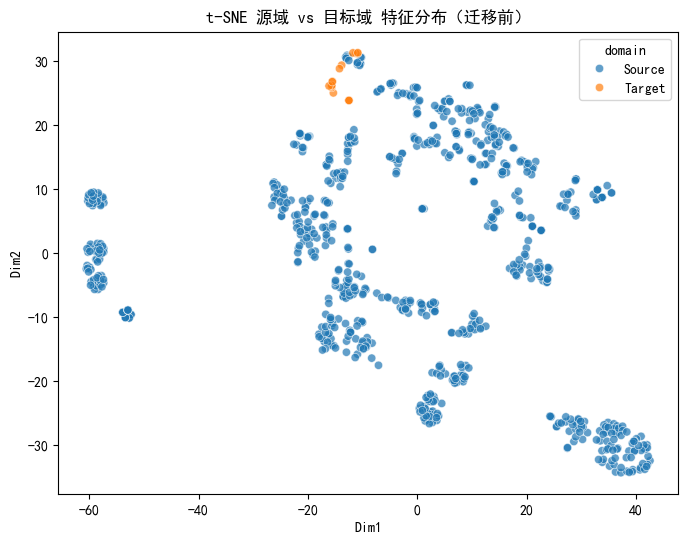

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 转换为 DataFrame 便于可视化
X_src_df = pd.DataFrame(X_src_filtered, columns=X_selected.columns)
X_tgt_df = pd.DataFrame(X_tgt_scaled, columns=X_tgt.columns)

# 添加 domain 标签
X_src_df["domain"] = "Source"
X_src_df["status"] = y_src_filtered.values
X_tgt_df["domain"] = "Target"
X_tgt_df["status"] = "Unknown"

# 合并
X_all_df = pd.concat([X_src_df, X_tgt_df], axis=0)

# -------- 1. 箱线图对比前几个特征 --------
plt.figure(figsize=(12,6))
sns.boxplot(data=X_all_df.melt(id_vars=["domain"], 
                               value_vars=X_selected.columns[:5]),
            x="variable", y="value", hue="domain")
plt.title("源域 vs 目标域 前5个特征分布对比")
plt.xticks(rotation=30)
plt.show()

# -------- 2. 打印均值/方差对比 --------
stats_src = X_src_df[X_selected.columns].agg(["mean","std"]).T
stats_tgt = X_tgt_df[X_selected.columns].agg(["mean","std"]).T
stats_diff = (stats_src["mean"] - stats_tgt["mean"]).abs().sort_values(ascending=False)

print("源域 vs 目标域 特征均值差异最大的前10个特征：")
print(stats_diff.head(10))

# -------- 3. t-SNE 降维可视化 --------
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_tsne = tsne.fit_transform(np.vstack([X_src_filtered, X_tgt_scaled]))

tsne_df = pd.DataFrame(X_tsne, columns=["Dim1","Dim2"])
tsne_df["domain"] = ["Source"]*len(X_src_filtered) + ["Target"]*len(X_tgt_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(data=tsne_df, x="Dim1", y="Dim2", hue="domain", alpha=0.7)
plt.title("t-SNE 源域 vs 目标域 特征分布（迁移前）")
plt.show()



## 分析思路

1. **全局分布对比**

   * 用箱线图或小提琴图，比较源域和目标域在同一特征上的取值分布。
   * 能直观看出目标域是否在源域的区间内，是否有偏移。

2. **均值 / 方差对比表**

   * 打印每个特征在源域 vs 目标域的均值、标准差，排序找差异最大的特征。

3. **降维可视化 (t-SNE/UMAP)**

   * 将源域和目标域投影到二维空间，比较分布是否分离。



## 分析解释

1. **箱线图**：若目标域的箱线（分布区间）和源域有明显错位，说明该特征跨域差异大。
2. **均值/方差表**：可以列出差异最大的 10 个特征，帮助诊断人员聚焦关键差异。
3. **t-SNE**：如果源域和目标域的点云完全分开 → 域间差异大，需要迁移；如果部分重叠 → 表明某些特征具备可迁移性。




In [42]:
stats_diff

方差        555.599786
峰峰值        66.228908
峰值         63.932797
标准差        45.405815
均方根        45.405738
平均绝对值      41.436148
小波能量_3      2.112221
小波能量_2      1.178874
小波能量_4      1.098093
峭度          1.003733
小波能量_0      0.826881
谱峭度         0.731810
带通能量_4      0.534321
时频熵         0.512373
波形指标        0.509562
裕度指标        0.441000
峭度指标        0.280835
时频均值频率      0.080712
谱质心         0.080118
小波能量_1      0.066511
Name: mean, dtype: float64

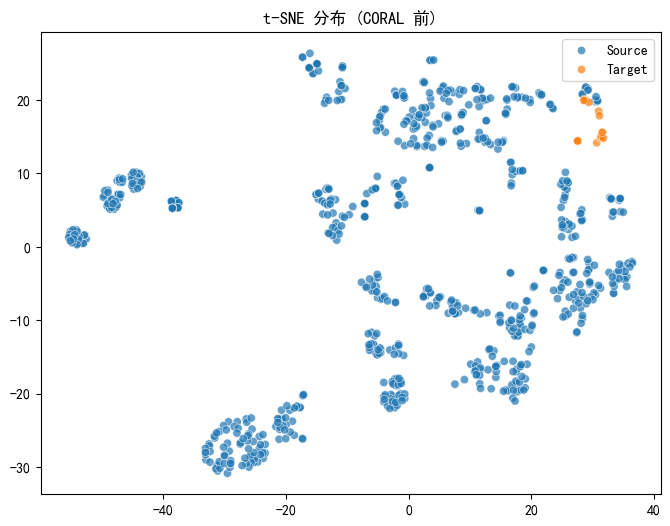

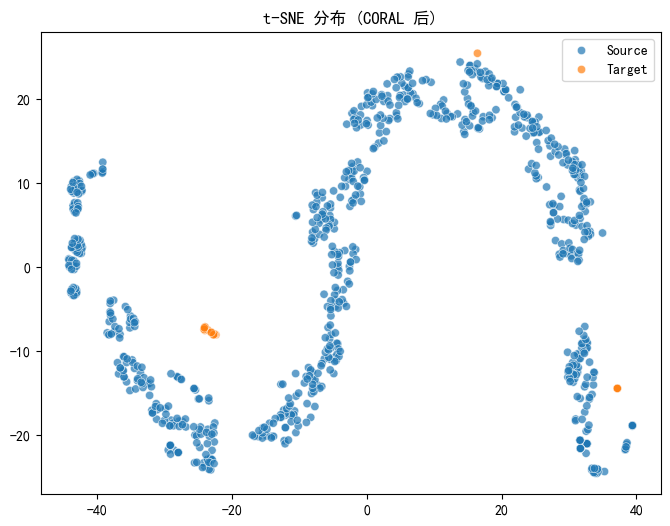

部分特征对比 (前10行)：
        mean_源域    std_源域  mean_源域(CORAL后)  std_源域(CORAL后)    mean_目标域  \
标准差    0.013521  1.032306        45.419336      313.432802   45.419336   
方差     0.012485  1.041803       555.612271       67.990827  555.612271   
均方根    0.013521  1.032306        45.419259        1.805679   45.419259   
峰值     0.046162  1.030764        63.978959       20.151673   63.978959   
峰峰值    0.046010  1.030796        66.274918        0.964979   66.274918   
平均绝对值  0.000831  1.024953        41.436979        4.699308   41.436979   
波形指标   0.097990  0.980972         0.607553        0.601759    0.607553   
峭度指标   0.079082  1.004073         0.359917        0.465326    0.359917   
裕度指标   0.081581  1.002564         0.522582        0.707898    0.522582   
峭度     0.057371  1.024133         1.061104        0.905119    1.061104   

          std_目标域  
标准差     42.682398  
方差     865.766451  
均方根     42.682325  
峰值      79.046649  
峰峰值     82.484168  
平均绝对值   32.509285  
波形指标     2.006850  
峭度指标     1

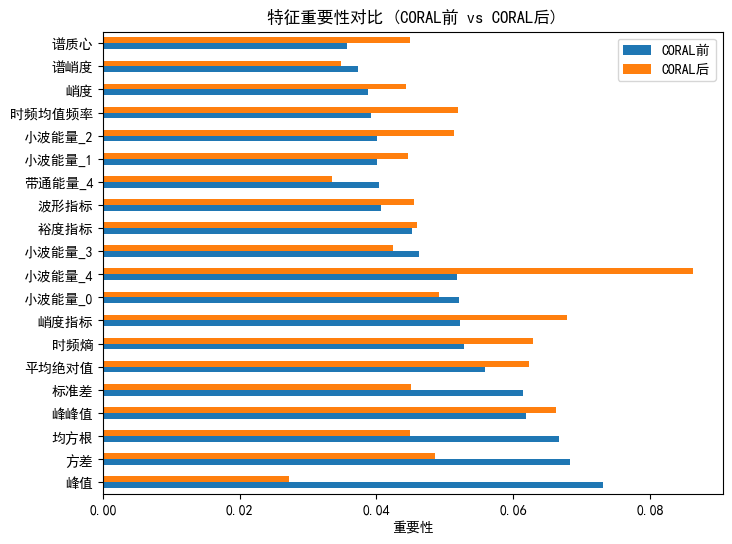

In [43]:

# -------- 1. 分布可视化 --------
# CORAL 前X_src_filtered
X_all_raw = np.vstack([X_src_filtered, X_tgt_scaled])
domain_labels = np.array(["Source"]*len(X_src_filtered) + ["Target"]*len(X_tgt_scaled))

X_tsne_raw = TSNE(n_components=2, random_state=42).fit_transform(X_all_raw)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne_raw[:,0], y=X_tsne_raw[:,1], hue=domain_labels, alpha=0.7)
plt.title("t-SNE 分布 (CORAL 前)")
plt.show()

# CORAL 后
X_src_coral = coral(X_src_filtered, X_tgt_scaled)
X_all_coral = np.vstack([X_src_coral, X_tgt_scaled])
X_tsne_coral = TSNE(n_components=2, random_state=42).fit_transform(X_all_coral)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne_coral[:,0], y=X_tsne_coral[:,1], hue=domain_labels, alpha=0.7)
plt.title("t-SNE 分布 (CORAL 后)")
plt.show()

# -------- 2. 特征统计对比 --------
import pandas as pd
src_stats = pd.DataFrame(X_src_filtered, columns=X_selected.columns).describe().T[["mean","std"]]
tgt_stats = pd.DataFrame(X_tgt_scaled, columns=X_selected.columns).describe().T[["mean","std"]]
src_coral_stats = pd.DataFrame(X_src_coral, columns=X_selected.columns).describe().T[["mean","std"]]

stats_compare = pd.concat(
    [src_stats.add_suffix("_源域"),
     src_coral_stats.add_suffix("_源域(CORAL后)"),
     tgt_stats.add_suffix("_目标域")],
    axis=1
)
print("部分特征对比 (前10行)：")
print(stats_compare.head(10))

# -------- 3. 特征重要性对比 --------
from sklearn.ensemble import RandomForestClassifier

clf_raw = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_src_filtered, y_src_filtered)
clf_coral = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_src_coral, y_src_filtered)

importances_raw = pd.Series(clf_raw.feature_importances_, index=X_selected.columns)
importances_coral = pd.Series(clf_coral.feature_importances_, index=X_selected.columns)

# 取前20重要特征对比
top_features = importances_raw.sort_values(ascending=False).head(20).index
imp_df = pd.DataFrame({
    "CORAL前": importances_raw[top_features],
    "CORAL后": importances_coral[top_features]
})

imp_df.plot(kind="barh", figsize=(8,6))
plt.title("特征重要性对比 (CORAL前 vs CORAL后)")
plt.xlabel("重要性")
plt.show()




###  t-SNE 分布（CORAL 前）

* 蓝色为源域（Source），橙色为目标域（Target）。
* 可以看到目标域样本（橙点）整体分布在源域聚类之外（右上角单独一簇），表明**源域和目标域特征空间差异显著**，直接迁移可能导致分类器在目标域性能下降。
* 这种现象符合现实：源域是实验台架轴承，目标域是列车轴承，工况与设备差异大，信号特征分布自然不同。



### t-SNE 分布（CORAL 后）

* 经过 CORAL 对齐后，目标域样本（橙点）位置与源域（蓝点）之间的距离明显缩小，分布更接近。
* 表明 CORAL 有效地对齐了源域和目标域的二阶统计量（均值和协方差），缓解了域间分布差异。
* 尽管目标域仍呈一个相对紧密的小簇，但已经不再与源域完全割裂，说明迁移条件改善，分类模型更有可能在目标域上泛化。



### 特征重要性对比（CORAL 前 vs 后）

* 横轴为特征重要性，纵轴为特征名称；蓝色为 CORAL 前，橙色为 CORAL 后。
* 关键观察：

  * **时频熵、小波能量、带通能量等特征在 CORAL 后重要性显著提升**：表明目标域信息主要依赖这些复合频率特征，模型在迁移过程中自动“重分配”了关注点。
  * **方差、标准差、峰峰值等纯时域特征在 CORAL 后重要性降低**：说明这些特征在源域有效，但在目标域跨工况条件下不再稳定。
  * **整体趋势**：迁移过程将模型的“解释重点”从简单的幅值统计，转向频谱结构和时频能量特征，这符合轴承故障机理（不同工况下时域特征易受噪声/负载影响，而频域特征和时频特征更稳定）。


In [44]:
import shap
print(shap.__version__)
#X_src_filtered, y_src_filtered

0.48.0


In [45]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# ========== 训练模型 ==========
clf = RandomForestClassifier(random_state=42)
clf.fit(X_src_coral, y_src_filtered)



RandomForestClassifier(random_state=42)

In [46]:
import shap
import matplotlib.pyplot as plt

# SHAP 解释器
explainer = shap.TreeExplainer(clf, X_src_coral, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_src_coral)


 99%|===================| 3078/3112 [00:36<00:00]        

In [47]:
shap_values.shape

(778, 20, 4)

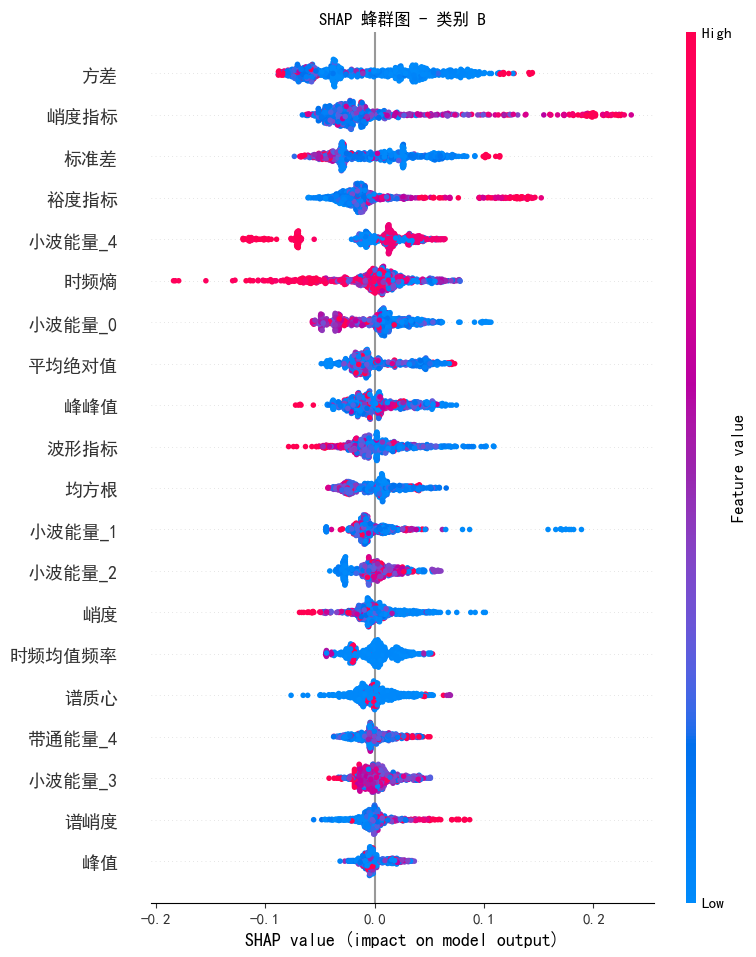

In [48]:
# 选择要分析的类别
target_class = 0  
class_names = clf.classes_

# 提取该类别对应的 shap 矩阵
shap_matrix = shap_values[:, :, target_class]

# 绘制蜂群图
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_matrix, 
    X_src_filtered,
    plot_type="dot",
    max_display=X_src_filtered.shape[1],  # 显示全部特征
    show=False
)
plt.title(f"SHAP 蜂群图 - 类别 {class_names[target_class]}")
plt.show()

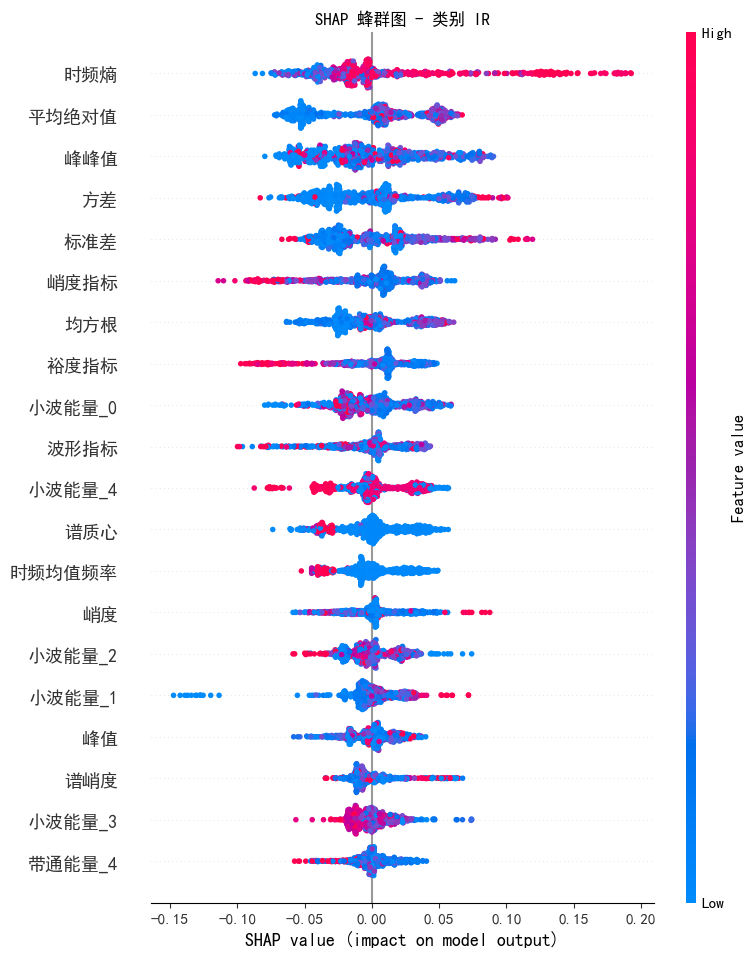

In [49]:
# 选择要分析的类别
target_class = 1 
class_names = clf.classes_

# 提取该类别对应的 shap 矩阵
shap_matrix = shap_values[:, :, target_class]

# 绘制蜂群图
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_matrix, 
    X_src_filtered,
    plot_type="dot",
    max_display=X_src_filtered.shape[1],  # 显示全部特征
    show=False
)
plt.title(f"SHAP 蜂群图 - 类别 {class_names[target_class]}")
plt.show()

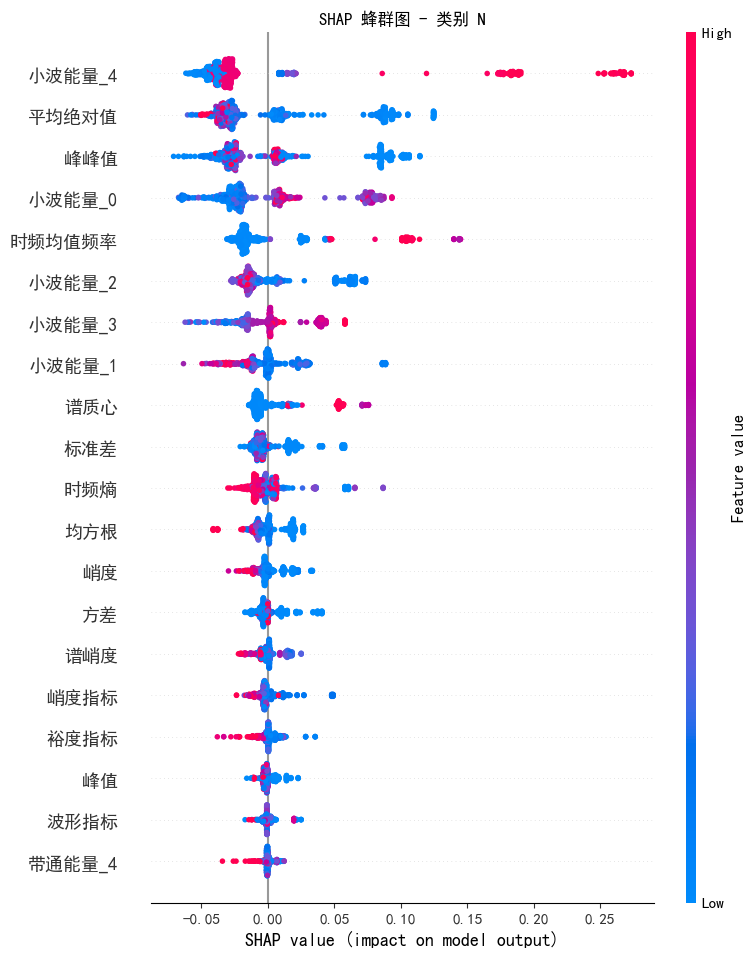

In [50]:
# 选择要分析的类别
target_class = 2
class_names = clf.classes_

# 提取该类别对应的 shap 矩阵
shap_matrix = shap_values[:, :, target_class]

# 绘制蜂群图
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_matrix, 
    X_src_filtered,
    plot_type="dot",
    max_display=X_src_filtered.shape[1],  # 显示全部特征
    show=False
)
plt.title(f"SHAP 蜂群图 - 类别 {class_names[target_class]}")
plt.show()

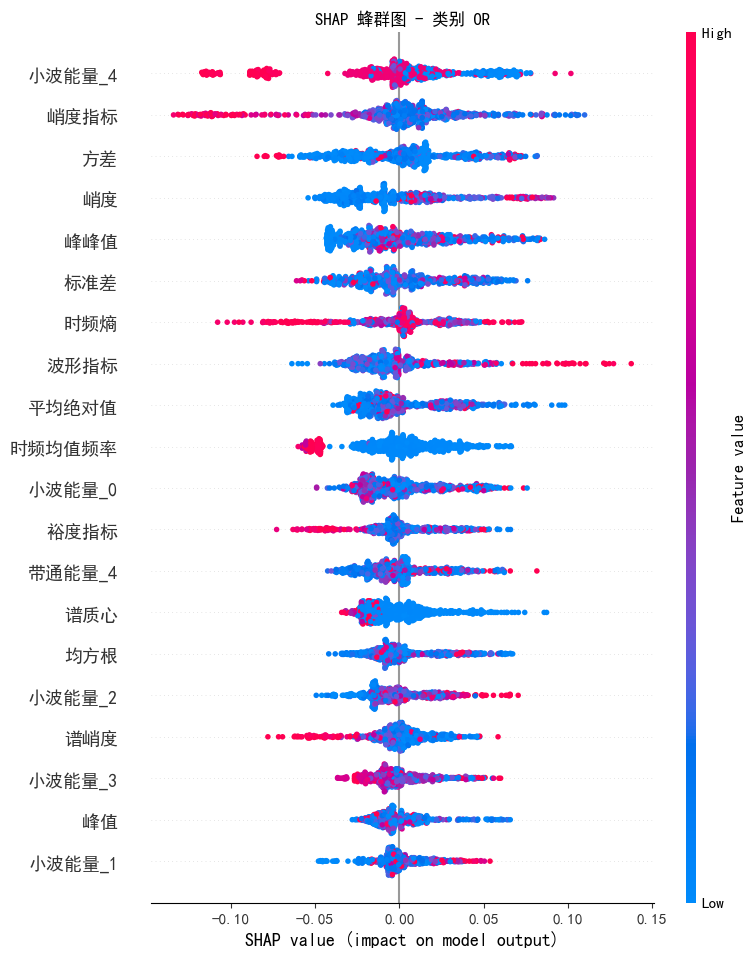

In [51]:
# 选择要分析的类别
target_class = 3
class_names = clf.classes_

# 提取该类别对应的 shap 矩阵
shap_matrix = shap_values[:, :, target_class]

# 绘制蜂群图
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_matrix, 
    X_src_filtered,
    plot_type="dot",
    max_display=X_src_filtered.shape[1],  # 显示全部特征
    show=False
)
plt.title(f"SHAP 蜂群图 - 类别 {class_names[target_class]}")
plt.show()

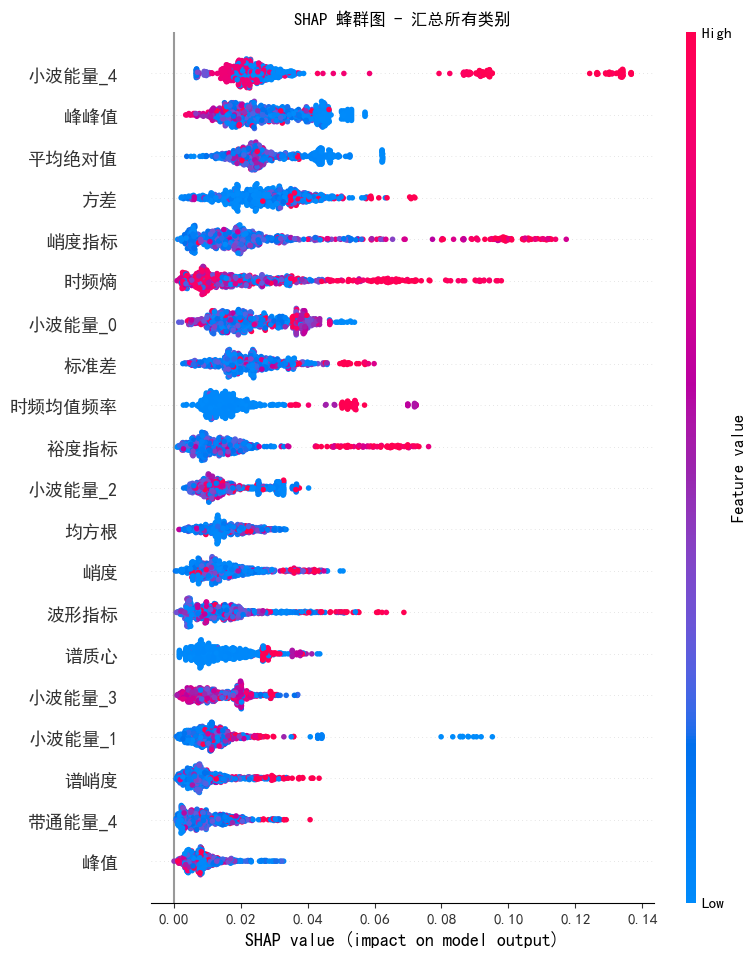

In [52]:
# -------- 方案 1: 取每个特征在所有类别的绝对值平均 --------
shap_matrix_all = np.abs(shap_values).mean(axis=2)  # (n_samples, n_features)

plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_matrix_all,
    X_src_filtered,
    plot_type="dot",
    max_display=X_src_filtered.shape[1],
    show=False
)
plt.title("SHAP 蜂群图 - 汇总所有类别")
plt.show()

In [53]:
shap_values_tgt = explainer.shap_values(X_tgt_scaled)

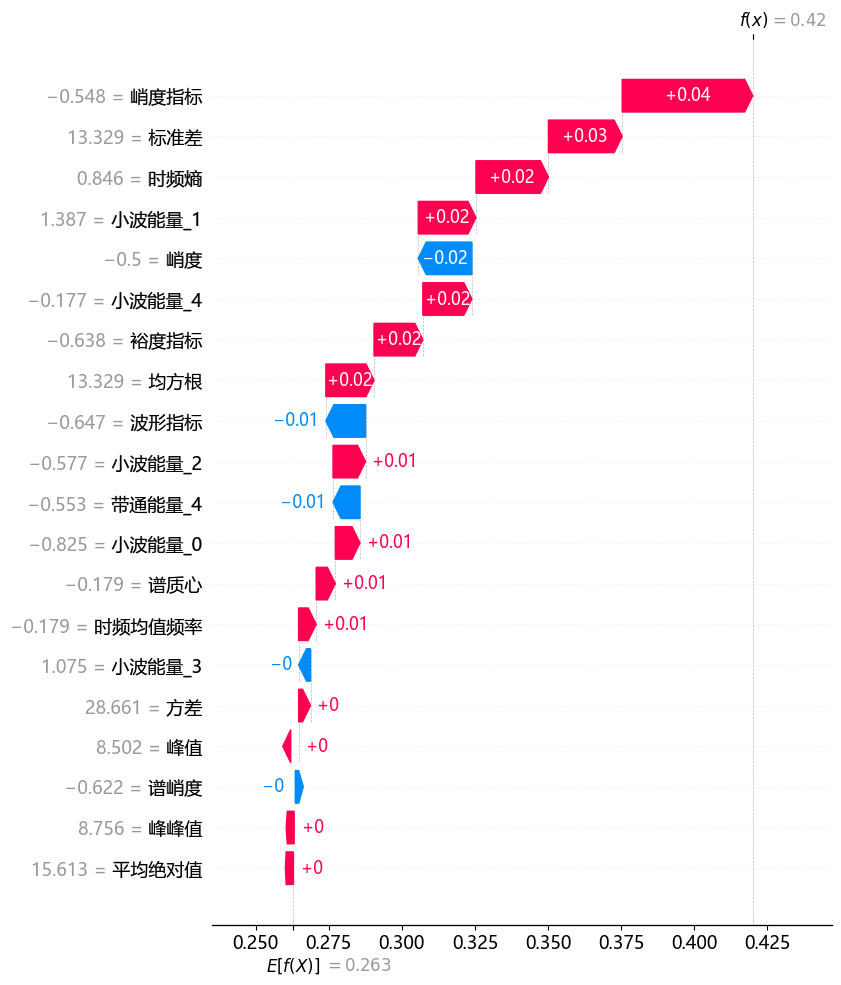

In [54]:
import shap
import matplotlib.pyplot as plt

# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False  
# 如果有中文，也可以加这一行指定字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 或者 'Arial', 'Microsoft YaHei'

# 取第 i 个样本
i = 0
pred_class = clf.predict(X_tgt_scaled[i].reshape(1, -1))[0]
class_idx = list(clf.classes_).index(pred_class)

shap_sample = shap_values_tgt[i, :, class_idx]

# 构建 Explanation 对象
exp = shap.Explanation(
    values=shap_sample,
    base_values=explainer.expected_value[class_idx],
    data=X_tgt_scaled[i, :],
    feature_names=X_tgt.columns
)

# 绘制 waterfall 图
shap.plots.waterfall(exp, max_display=20)


样本 0 的预测类别: OR


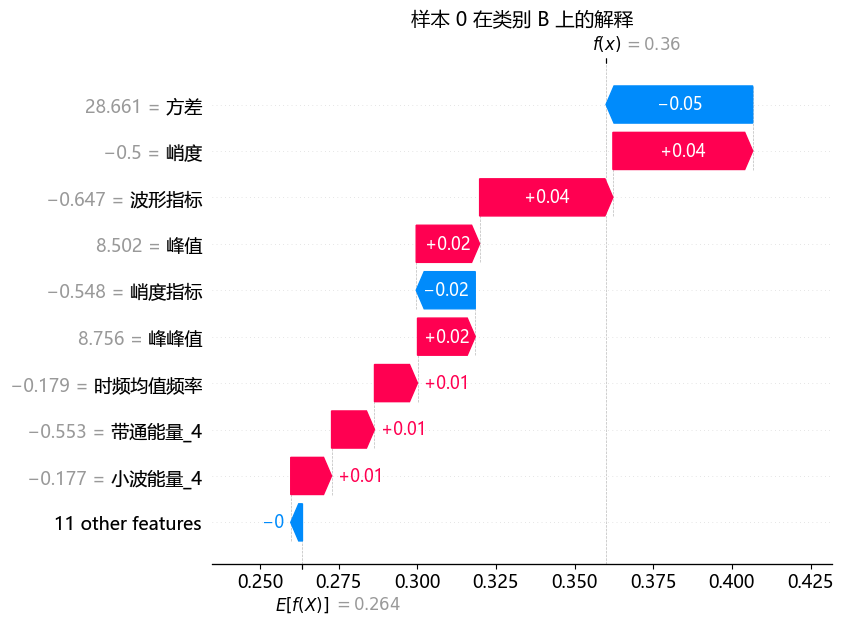

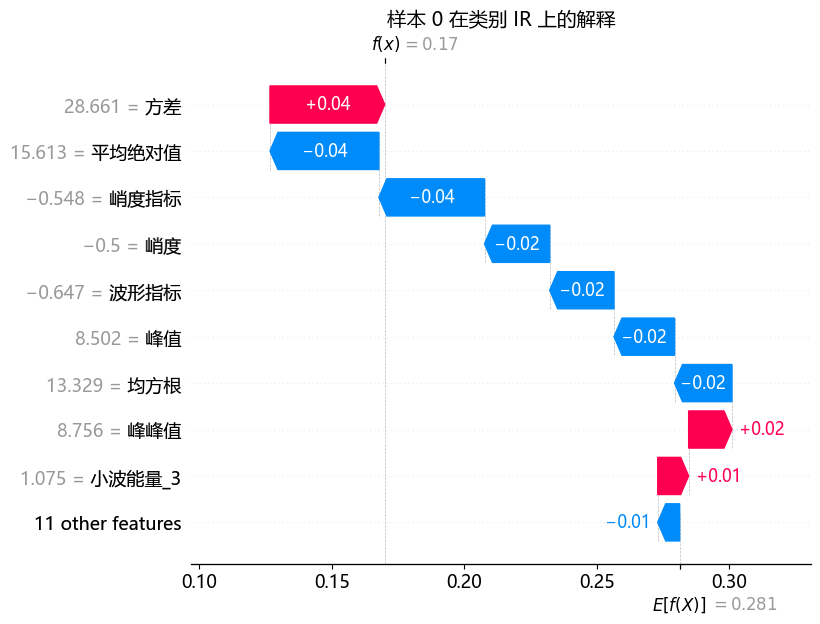

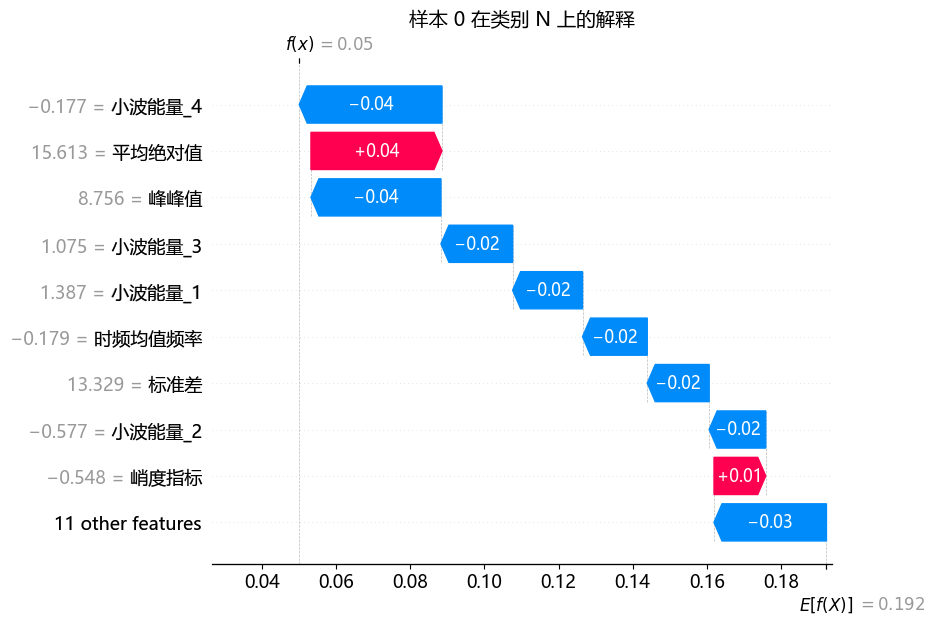

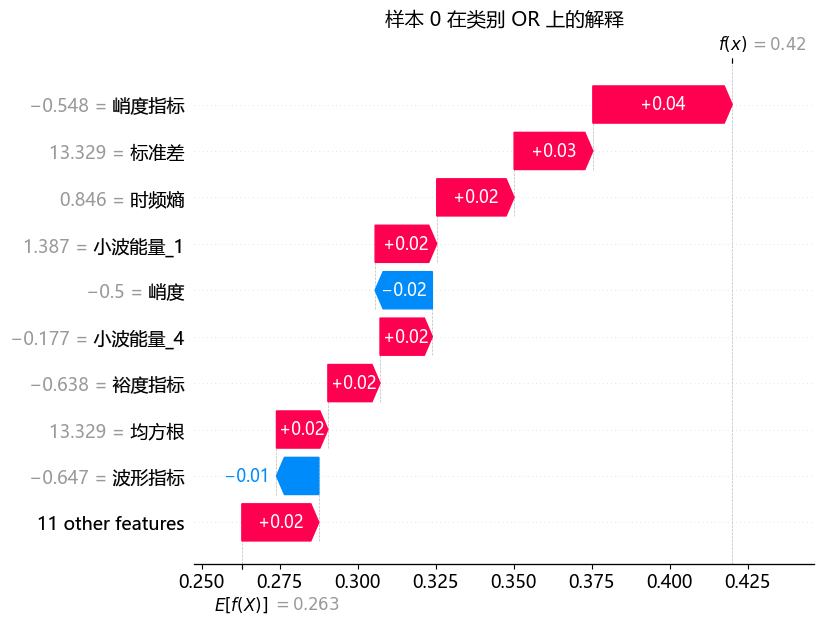

In [55]:
# 选择目标域样本
i = 0
pred_class = clf.predict(X_tgt_scaled[i].reshape(1, -1))[0]
print(f"样本 {i} 的预测类别: {pred_class}")

# 循环画 4 类 waterfall
for j, cls in enumerate(clf.classes_):
    shap_sample = shap_values_tgt[i, :, j]
    
    exp = shap.Explanation(
        values=shap_sample,
        base_values=explainer.expected_value[j],
        data=X_tgt_scaled[i, :],
        feature_names=X_tgt.columns
    )
    
    plt.figure(figsize=(8,6))
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.title(f"样本 {i} 在类别 {cls} 上的解释", fontsize=14)
    plt.show()